# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3. Генерация признаков

### Общая информация

Дата выдачи: 19.10.2025

Мягкий дедлайн: 04.11.2025 23:59MSK

Жесткий дедлайн: 08.11.2025 23:59MSK

### О задании

В данном задании необходимо реализовать самые ходовые техники для создания новых признаков в табличном машинном обучении. Вам понадобиться применить всю вашу фантазию, чтобы собрать наилучшие признаки для решения задачи линейной классификации и победы в соревновании

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 11 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-features-Username.ipynb**, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: 7

### **Задание 1. Вводная часть (1 балл)** <img align="center" height=25 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

<img style="float: right; padding-right:10px" src="https://media.discordapp.net/attachments/674191702906503199/1429321721495949392/pomoika2.png?ex=68f5b715&is=68f46595&hm=f6664e6068c19ab5606c40ca6ef92c093cb343b8b96c471c3d8927dc4569552c&=&format=webp&quality=lossless&width=432&height=648" height=400></img>
    
В этом домашнем задании мы будем работать с датасетом по широко известной в неузких кругах видеоигре Dota 2. Если вы не знакомы с ней - ничего страшного, все необходимое для задания мы подробно опишем. Также, как ни странно, не стесняйтесь спрашивать у гугла, гпт или, прости Господи, дотеров, если вам что-то не ясно.

Подробное описание данных настолько большое, что описано отдельно на страничке соревнования.

Очень краткое описание игры:
- Dota 2 - это командная игра, в которой принимает участие 5 игроков со стороны Radiant и 5 игроков со стороны Dire;
- каждый из игроков выбирает своего героя, все герои в одной игре разные, у каждого героя есть ряд атрибутов, которые сильно отличают его от других;
- цель игроков - снести главную постройку вражеской стороны (в простонародье - трон);
- игроки могут зарабатывать деньги, убивать персонажей вражеской команды, чтобы становиться сильнее и легче снести этот самый трон;
- игра всегда заканчивается победой одной стороны, может идти от 0 минут до бесконечности.

Мы будем пытаться предсказать исход матча - победа или поражение, исходя из разных факторов, с которыми мы познакомимлся ниже. По задумке мы пытаемся предсказать матчи, которые едва начались (например, чтобы делать ставки на спорт), поэтому ряд данных на тестовой выборке отсутствует. Целевая метрика уже выбрана за нас: мы будем считать ROC-AUC, но не простой, а коэффициент Джини, чтобы избегать странных значений метрики меньше $0.5$:

$$ \text{Gini} = | 2 \cdot \text{ROCAUC} - 1 |$$

#### **Важнейшее замечание!!!**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы все трансформы ложились четко, все шейпы датафреймов стакались, все нужные джойны джойнились;
- когда ваша модель хуже или лучше, как это проверять и как подбирать гиперпараметры (валидация - наш лучший друг, иногда даже лучше настоящих);
- на какой выборке делать `fit`, а на какой `transform`, чтобы не допустить утечки данных;
- как базово кодировать признаки, чтобы ваша модель вообще обучалась (без нормализации никуда, если используем регуляризацию, категории обязательно кодируем);
- как рисовать читаемые графики.

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, может это и неплохо).

> Мы верим, что вы уже достаточно взрослые и самостоятельные, чтобы верно принимать жизненные решения, поэтому большая часть этой домашки не имеет четких критериев успеха, кроме факта выполненного задания.

> Максимум за эту часть домашки — 8 баллов; чтобы добить оставшиеся, вам придется посоревноваться с вашими любимыми сокурсниками.

> Впрочем, для победы в соревновании вам может понадобиться сделать все из них и, скорее всего, даже больше.

> То, насколько эти задания вам помогут, зависит исключительно от вас: какие-то преобразования признаков заходят лучше, какие-то хуже, но гарантируется, что каждое из них может помочь.

> Вы вольны делать любые пункты, которые вам больше нравятся. Для этого мы прикладываем схему, которую желательно изучить, прежде чем приступать к выполнению задания.

<img src="https://i.postimg.cc/K8qYFHyv/image-2025-10-19-164454599.png"></img>

In [ ]:
from sklearn.metrics import roc_auc_score
from typing import Optional, Callable


def gini(y_true, y_score):
    return abs(2 * roc_auc_score(y_true, y_score) - 1.0)

#### Задание 1.1. Знакомство с данными (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно загрузить. В рамках этого ноутбука нам потребуются:

1. Информация о матчах - `matches_df_train.csv`.
2. Информация об игроках - `player_df.csv`.
3. Информация о героях - `Constants.Heroes.csv`.
4. Информация о статистиках матча - `dota_adv.csv`.
5. Тестовые данные для соревнования - `matches_df_test.csv`.

Дополнительные данные, при остром желании, можно попробовать стащить [отсюда](https://www.kaggle.com/datasets/bwandowando/dota-2-pro-league-matches-2023), но в обязательную часть это не входит.

Первое задание максимально скучное:

1. Посмотрите на все датафреймы выше - какие в них колонки, по какому признаку их можно джойнить между собой, на типы и тд.
2. Проверьте, есть ли в данных пропуски, дубли, выбросы, и хотите ли вы что-то с ними сделать.
3. Разбейте данные на трейн и валидацию (доля разбиения - на ваше усмотрение).
4. Найдите, где же наш таргет, и постройте график его распределения на трейне и валидации.
5. Сделайте вывод: подходящая ли в данном случае метрика Gini? Аргументируйте ваш ответ.

In [19]:
# ヾ(⌐■_■)ノ♪ your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [40]:
matches_df_train = pd.read_csv('matches_df_train.csv')
player_df = pd.read_csv('player_df.csv')
Constants_Heroes = pd.read_csv('Constants.Heroes.csv')
dota_adv = pd.read_csv('dota_adv.csv')
matches_df_test = pd.read_csv('matches_df_test.csv')

создадим функции для быстрого анализа и вывода графиков

In [2]:
def analyse(df):
    """
    вывод базоого описания датафрейма
    """
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_colwidth', None)

    print('размер датафрейма')
    print(df.shape)
    print('\nсписок колонок')
    print((', '.join(df.columns.tolist())))
    print('\nпропущеные значения в %')
    print(df.isna().mean() * 100)
    print('\nналичие дубликатов')
    print(df.duplicated().sum())


def plots(df):
    """
    построение графиков
    """
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    print('\nраспределения числовых признаков')
    if len(num_cols) > 0:
        n = len(num_cols)
        rows = int(np.ceil(n / 3))
        fig, axes = plt.subplots(rows, 3, figsize=(10, 3 * rows))
        axes = axes.flatten()
        for i, col in enumerate(num_cols):
            df[col].hist(bins=30, ax=axes[i])
            axes[i].set_title(col)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()

        print('\nбоксплоты числовых признаков')
        fig, axes = plt.subplots(rows, 3, figsize=(10, 2 * rows))
        axes = axes.flatten()
        for i, col in enumerate(num_cols):
            sns.boxplot(x=df[col], ax=axes[i])
            axes[i].set_title(col)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()

    print('\nраспределения категориальных признаков')
    if len(cat_cols) > 0:
        n = min(len(cat_cols), 6)
        rows = int(np.ceil(n / 3))
        fig, axes = plt.subplots(rows, 3, figsize=(10, 3 * rows))
        axes = axes.flatten()
        for i, col in enumerate(cat_cols[:n]):
            df[col].value_counts(dropna=False).head(10).plot(kind='bar', ax=axes[i])
            axes[i].set_title(col)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()


размер датафрейма
(706870, 6)

список колонок
match_id, date, region, game_mode, duration, radiant_win

пропущеные значения в %
match_id       0.0
date           0.0
region         0.0
game_mode      0.0
duration       0.0
radiant_win    0.0
dtype: float64

наличие дубликатов
0

распределения числовых признаков


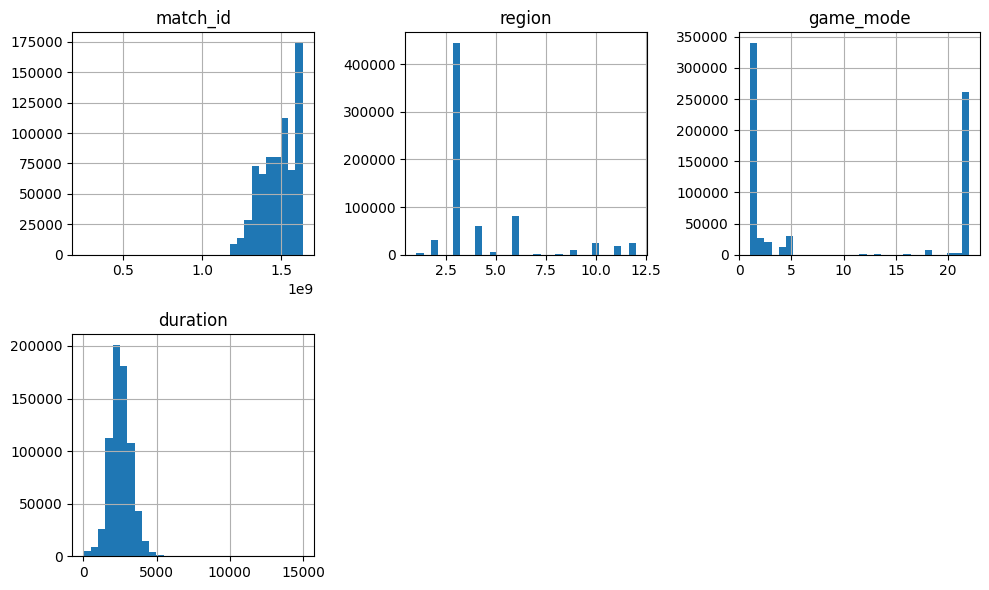


боксплоты числовых признаков


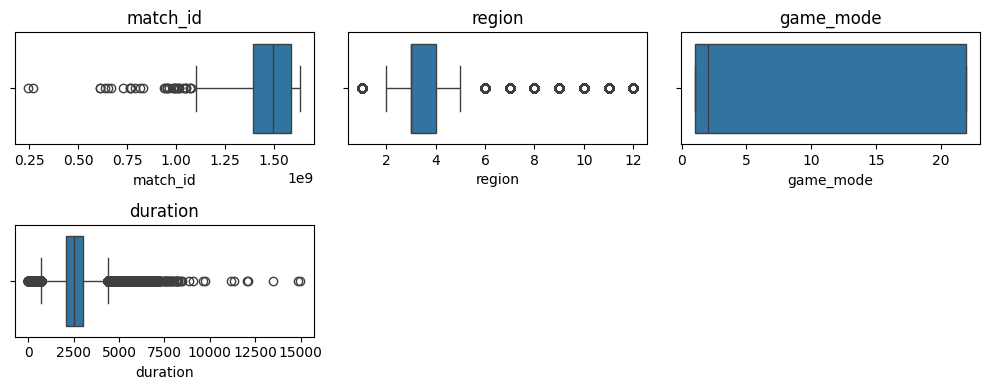


распределения категориальных признаков


,match_id,date,region,game_mode,duration,radiant_win
0,1606558457,2024-01-01,3,1,50,True
1,1533104773,2024-01-01,3,1,86,True
2,1494396881,2024-01-01,3,1,211,True
3,1457581060,2024-01-01,3,1,270,True
4,1590242915,2024-01-01,3,21,318,True


In [21]:
analyse(matches_df_train)
plots(matches_df_train)
matches_df_train.head()


распределение длительности матча с тяжелым хвостом- логично, так как матч может дляться от 0 до беск минут. пропущеных значений нет. дубликаты стоит удалить.

размер датафрейма
(7650825, 14)

список колонок
player_slot, account_id, hero_id, kills, deaths, assists, gold, last_hits, denies, gold_per_min, xp_per_min, hero_damage, tower_damage, match_id

пропущеные значения в %
player_slot     0.000000
account_id      0.000000
hero_id         0.000000
kills           7.940242
deaths          7.940242
assists         7.940242
gold            7.940242
last_hits       7.940242
denies          7.940242
gold_per_min    7.940242
xp_per_min      7.940242
hero_damage     7.940242
tower_damage    7.940242
match_id        0.000000
dtype: float64

наличие дубликатов
0

распределения числовых признаков


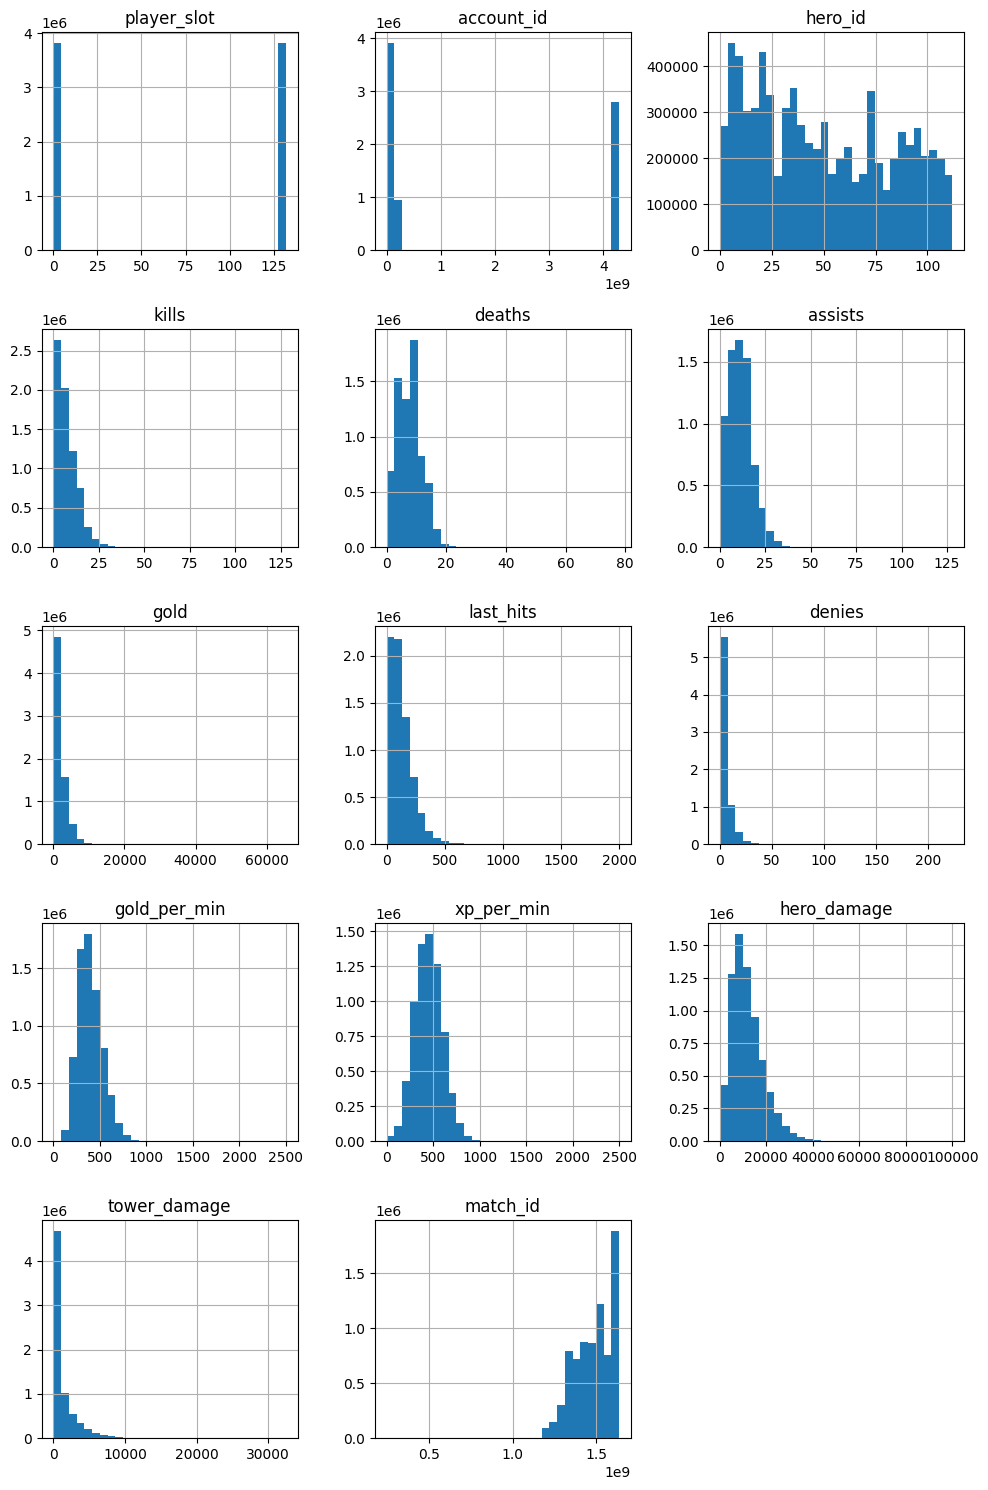


боксплоты числовых признаков


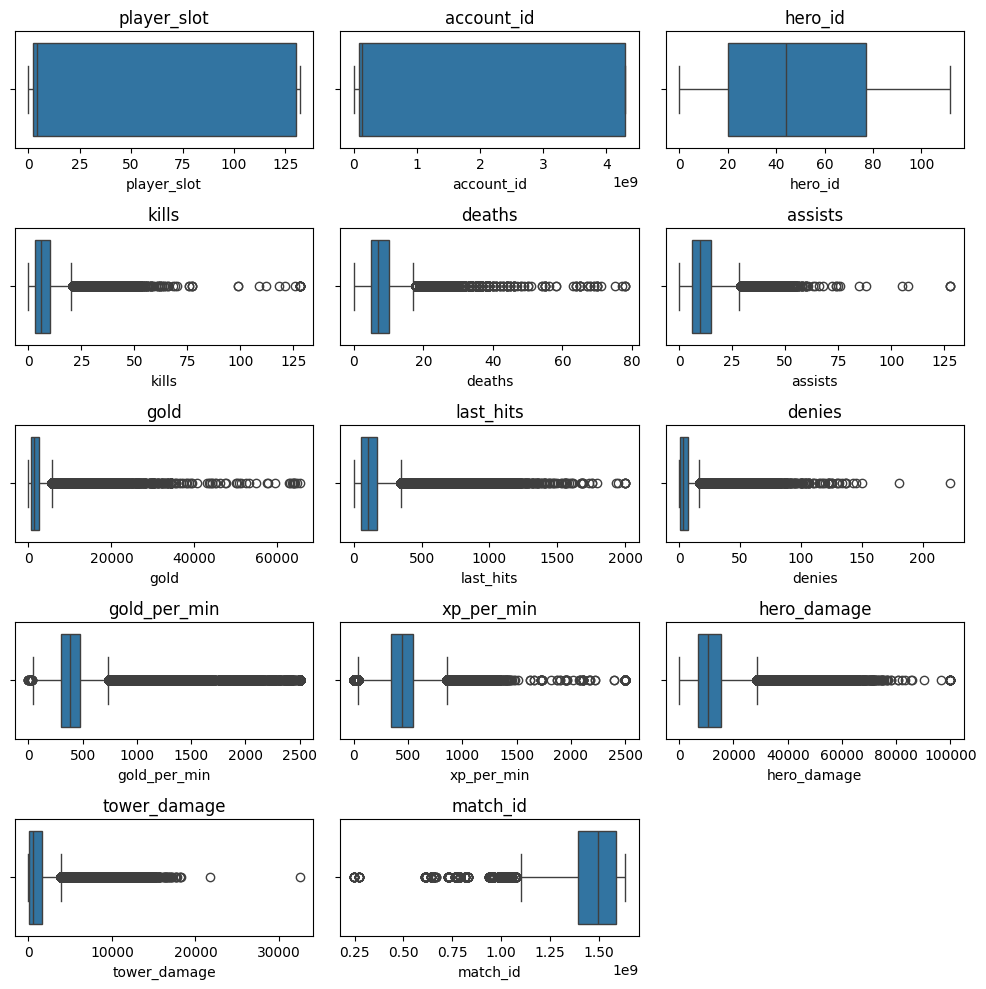


распределения категориальных признаков


,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,1411590681
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,1388958799
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,1587246664
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,1490278157
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,1526223166


In [20]:
analyse(player_df)
plots(player_df)
player_df.head()

почти все распределения числовых признаков несимметричны, что логично для специфики игры. пропущенных значений немного

размер датафрейма
(126, 34)

список колонок
Unnamed: 0, id, name, primary_attr, attack_type, roles, img, icon, base_health, base_health_regen, base_mana, base_mana_regen, base_armor, base_mr, base_attack_min, base_attack_max, base_str, base_agi, base_int, str_gain, agi_gain, int_gain, attack_range, projectile_speed, attack_rate, base_attack_time, attack_point, move_speed, turn_rate, cm_enabled, legs, day_vision, night_vision, localized_name

пропущеные значения в %
Unnamed: 0            0.000000
id                    0.000000
name                  0.000000
primary_attr          0.000000
attack_type           0.000000
roles                 0.000000
img                   0.000000
icon                  0.000000
base_health           0.000000
base_health_regen     0.793651
base_mana             0.000000
base_mana_regen       0.000000
base_armor            0.000000
base_mr               0.000000
base_attack_min       0.000000
base_attack_max       0.000000
base_str              0.000000
bas

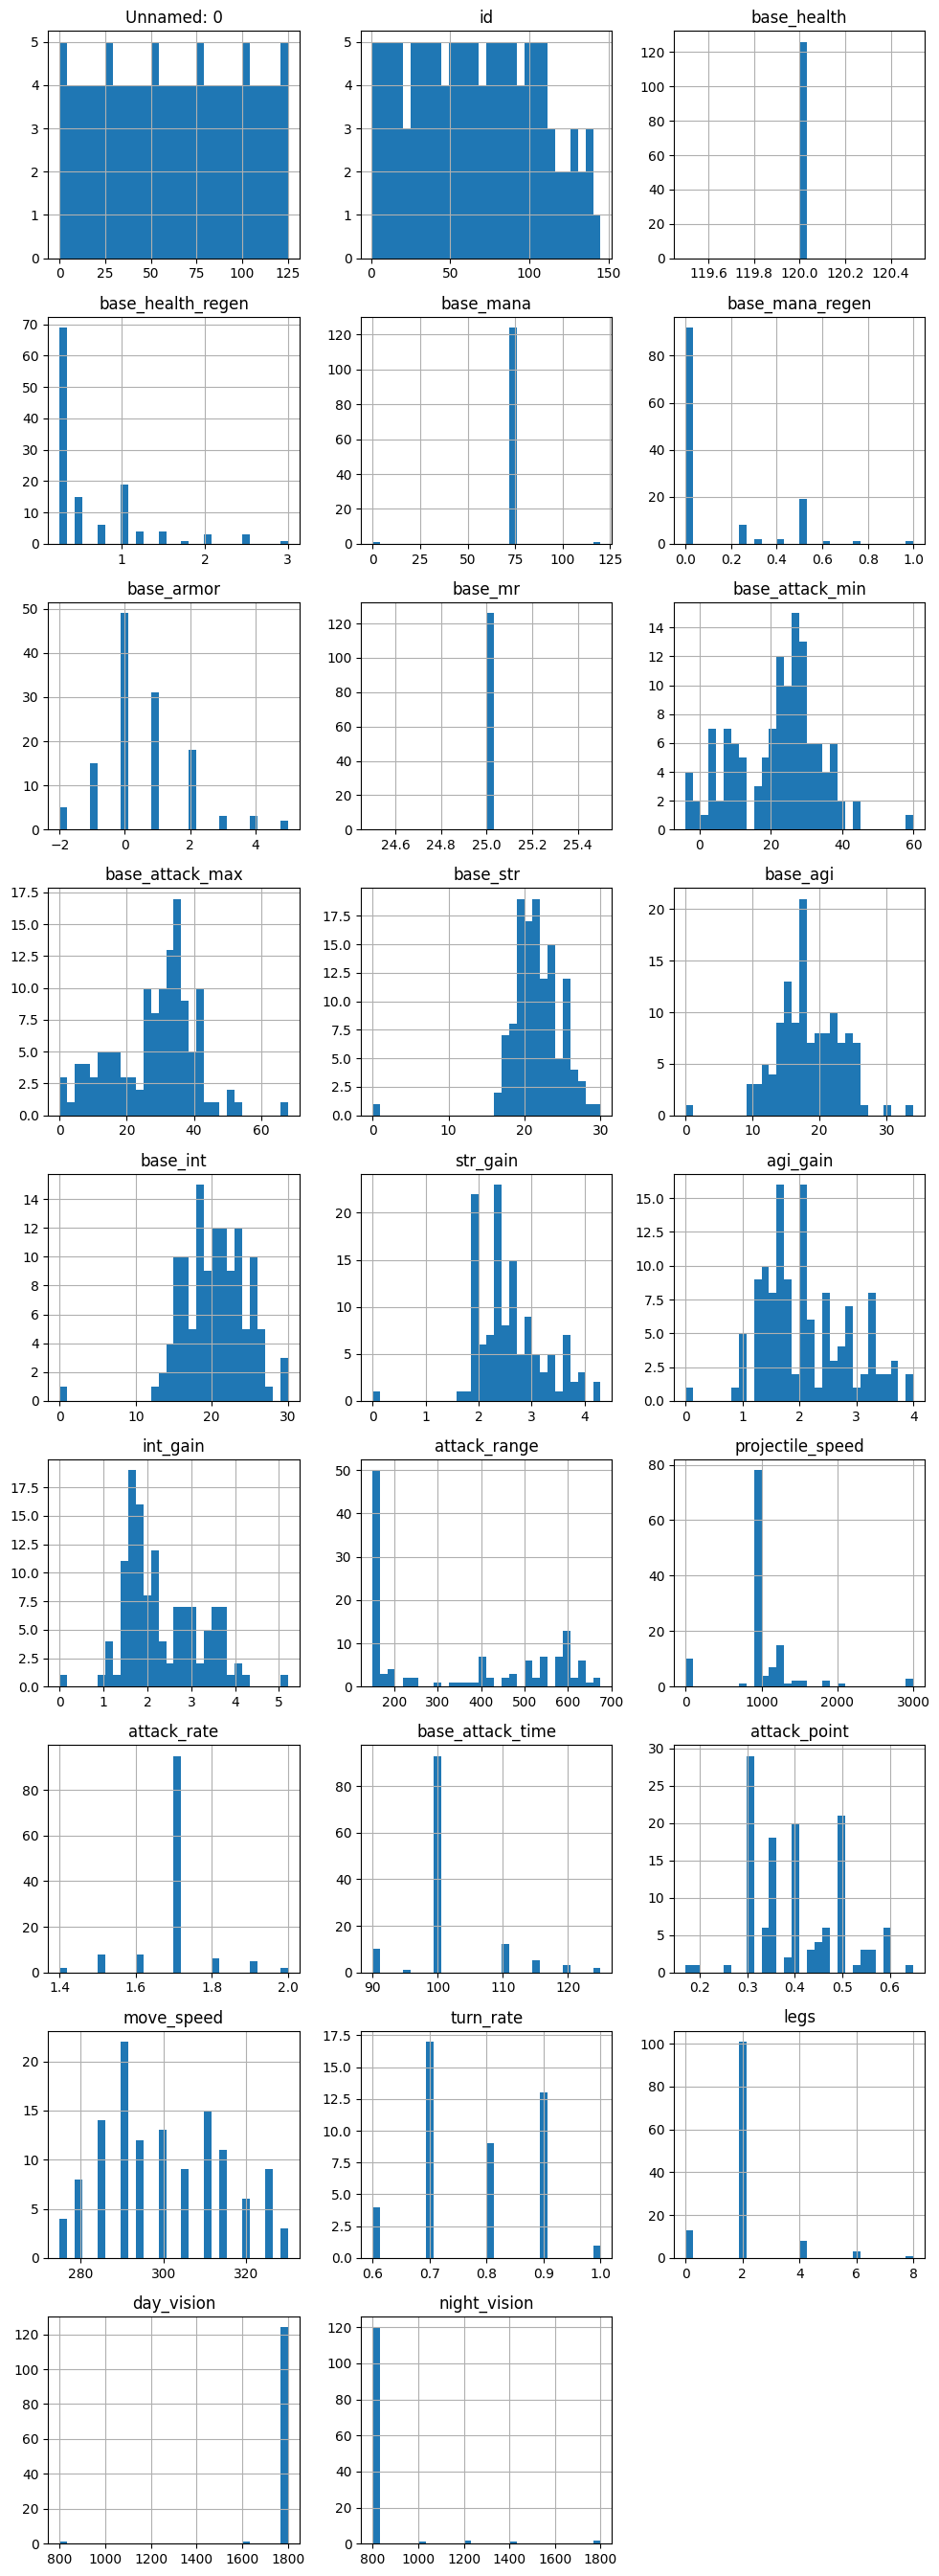


боксплоты числовых признаков


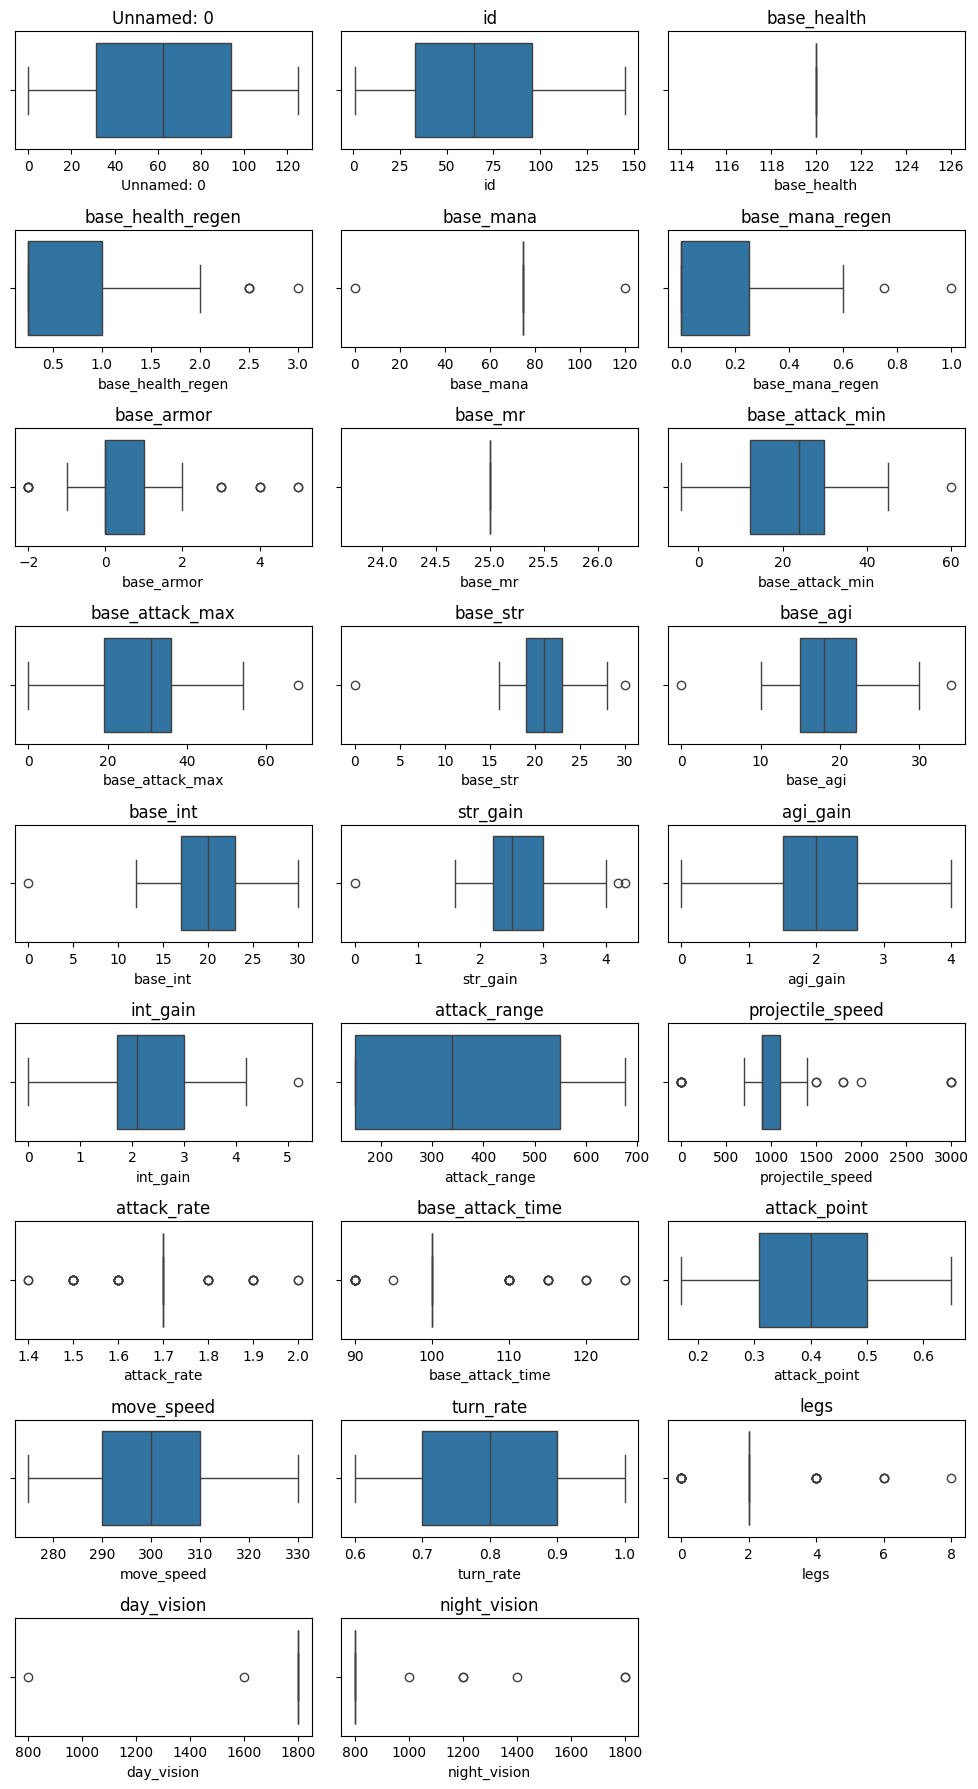


распределения категориальных признаков


/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_5148/1588589241.py:63: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


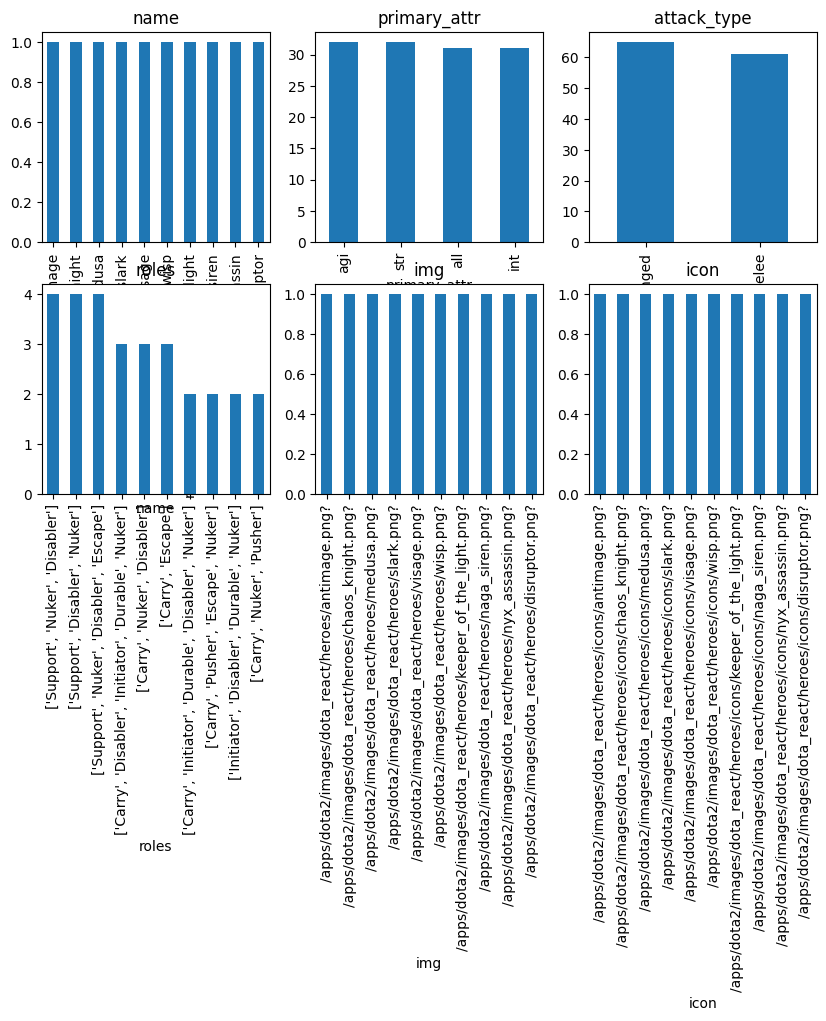

,Unnamed: 0,id,name,primary_attr,attack_type,roles,img,icon,base_health,base_health_regen,base_mana,base_mana_regen,base_armor,base_mr,base_attack_min,base_attack_max,base_str,base_agi,base_int,str_gain,agi_gain,int_gain,attack_range,projectile_speed,attack_rate,base_attack_time,attack_point,move_speed,turn_rate,cm_enabled,legs,day_vision,night_vision,localized_name
0,0,1,npc_dota_hero_antimage,agi,Melee,"['Carry', 'Escape', 'Nuker']",/apps/dota2/images/dota_react/heroes/antimage.png?,/apps/dota2/images/dota_react/heroes/icons/antimage.png?,120,1.00,75,0.0,1,25,29,33,19,24,12,1.6,2.8,1.8,150,0,1.4,100,0.30,310,NaN,True,2,1800,800,Anti-Mage
1,1,2,npc_dota_hero_axe,str,Melee,"['Initiator', 'Durable', 'Disabler', 'Carry']",/apps/dota2/images/dota_react/heroes/axe.png?,/apps/dota2/images/dota_react/heroes/icons/axe.png?,120,2.50,75,0.0,0,25,30,34,25,20,18,2.8,1.7,1.6,150,900,1.7,100,0.40,315,NaN,True,2,1800,800,Axe
2,2,3,npc_dota_hero_bane,all,Ranged,"['Support', 'Disabler', 'Nuker', 'Durable']",/apps/dota2/images/dota_react/heroes/bane.png?,/apps/dota2/images/dota_react/heroes/icons/bane.png?,120,0.25,75,0.0,1,25,-1,5,23,23,23,2.7,2.7,2.7,400,900,1.7,100,0.30,305,NaN,True,4,1800,1200,Bane
3,3,4,npc_dota_hero_bloodseeker,agi,Melee,"['Carry', 'Disabler', 'Nuker', 'Initiator']",/apps/dota2/images/dota_react/heroes/bloodseeker.png?,/apps/dota2/images/dota_react/heroes/icons/bloodseeker.png?,120,0.25,75,0.0,2,25,35,41,24,24,17,2.7,3.1,2.0,150,900,1.7,100,0.43,285,NaN,True,2,1800,800,Bloodseeker
4,4,5,npc_dota_hero_crystal_maiden,int,Ranged,"['Support', 'Disabler', 'Nuker']",/apps/dota2/images/dota_react/heroes/crystal_maiden.png?,/apps/dota2/images/dota_react/heroes/icons/crystal_maiden.png?,120,0.25,75,0.0,0,25,30,36,17,16,18,2.2,1.8,3.3,600,900,1.7,100,0.45,280,NaN,True,2,1800,800,Crystal Maiden


In [18]:
analyse(Constants_Heroes)
plots(Constants_Heroes)
Constants_Heroes.head()

распределения категориальных признаков неинформативны

размер датафрейма
(767822, 3)

список колонок
match_id, radiant_gold_adv, radiant_exp_adv

пропущеные значения в %
match_id            0.0
radiant_gold_adv    0.0
radiant_exp_adv     0.0
dtype: float64

наличие дубликатов
0

распределения числовых признаков


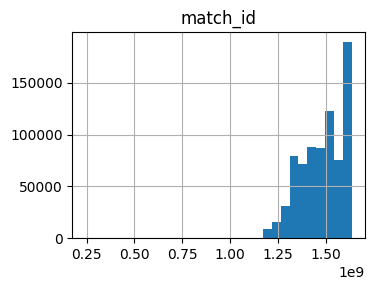


боксплоты числовых признаков


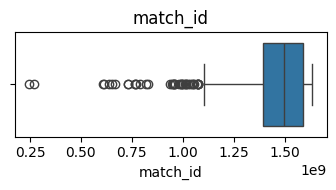


распределения категориальных признаков


/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_5148/1588589241.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


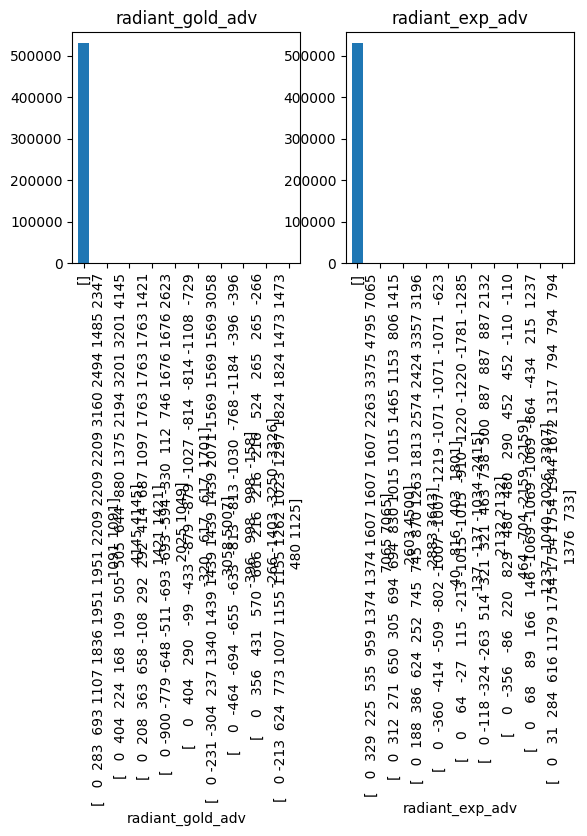

,match_id,radiant_gold_adv,radiant_exp_adv
0,1340959379,[],[]
1,1377521758,[],[]
2,1457973639,[],[]
3,1629821522,[],[]
4,1529300845,[ 0 334 179 655 31 1029 1029 1029 662 30 30 759 77 1155\n 2969 2969],[ 0 147 105 -9 -651 -471 -471 -723 -441 -970 -537 449\n 449 -5 -1272 -1272]


In [22]:
analyse(dota_adv)
plots(dota_adv)
dota_adv.head()

размер датафрейма
(60953, 4)

список колонок
match_id, date, region, game_mode

пропущеные значения в %
match_id     0.0
date         0.0
region       0.0
game_mode    0.0
dtype: float64

наличие дубликатов
0

распределения числовых признаков


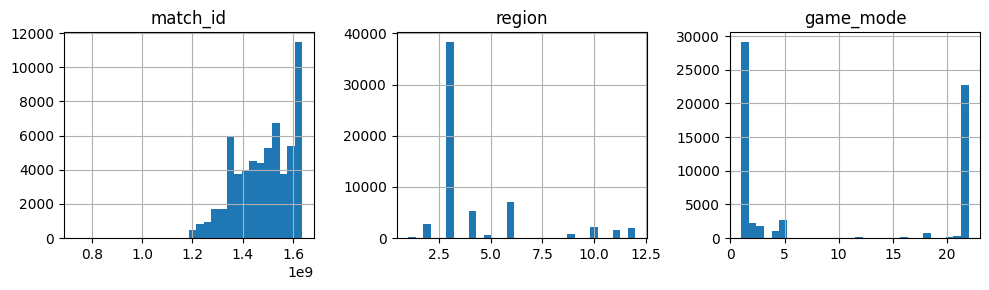


боксплоты числовых признаков


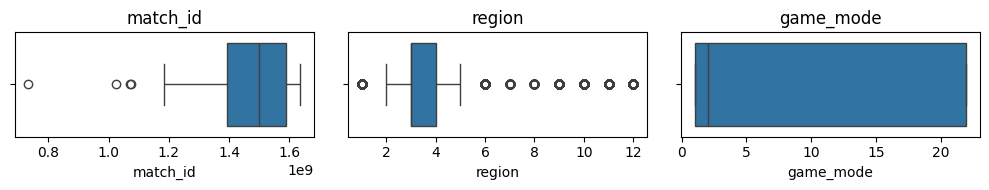


распределения категориальных признаков


,match_id,date,region,game_mode
0,1509410699,2024-12-14,6,22
1,1307322096,2024-12-15,12,22
2,1427032882,2024-12-03,3,1
3,1335981501,2024-12-29,3,1
4,1305100719,2024-12-23,3,22


In [23]:
analyse(matches_df_test)
plots(matches_df_test)
matches_df_test.head()

удалим дубликаты

In [31]:
matches_df_train = matches_df_train.drop_duplicates(subset=["match_id"]).reset_index(drop=True)
matches_df_test = matches_df_test.drop_duplicates(subset=["match_id"]).reset_index(drop=True)
dota_adv = dota_adv.drop_duplicates(subset=["match_id"]).reset_index(drop=True)

преобразуем даты

In [16]:
matches_df_train['date'] = pd.to_datetime(matches_df_train['date'], errors='coerce')
matches_df_test['date'] = pd.to_datetime(matches_df_test['date'], errors='coerce')

посмотрим, какие колоник общие в датасетах

In [32]:
import itertools

datasets = {
    "matches_df_train": matches_df_train,
    "player_df": player_df,
    "Constants_Heroes": Constants_Heroes,
    "dota_adv": dota_adv,
    "matches_df_test": matches_df_test
}

for (name1, df1), (name2, df2) in itertools.combinations(datasets.items(), 2):
    common_cols = set(df1.columns).intersection(df2.columns)
    if common_cols:
        print(f"Общие колонки между {name1} и {name2}: {common_cols}")


Общие колонки между matches_df_train и player_df: {'match_id'}
Общие колонки между matches_df_train и dota_adv: {'match_id'}
Общие колонки между matches_df_train и matches_df_test: {'match_id', 'date', 'game_mode', 'region'}
Общие колонки между player_df и dota_adv: {'match_id'}
Общие колонки между player_df и matches_df_test: {'match_id'}
Общие колонки между dota_adv и matches_df_test: {'match_id'}


можно мерджить по match_id

таргет - radiant_win. 

так как мы предсказываем результат на уровне матча, ужно объединить датафреймы. как вариант, можно было бы сделать мультииндексный датафрейм: он хранит иерархические данные, но ML-модели не умеют работать с такой структурой.

так что соберем статистику всех игроков матча в одну строку, усредним, вычислим агрегаты.

переименуем колонки

In [41]:
heroes_df = Constants_Heroes.rename(columns={'id': 'hero_id'})[
    ['hero_id', 'primary_attr', 'attack_type', 'move_speed', 'base_attack_min', 'base_attack_max']
]

преобразуем 'radiant_gold_adv' и 'radiant_exp_adv', так как в них хранятся строки с числами

In [42]:
for col in ['radiant_gold_adv', 'radiant_exp_adv']:
    dota_adv[col] = [
        np.array([int(i) for i in x.strip('[]').split()]) if isinstance(x, str) else np.nan
        for x in dota_adv[col]
    ]

    dota_adv[f'{col}_final'] = [x[-1] if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in dota_adv[col]]
    dota_adv[f'{col}_mean']  = [np.mean(x) if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in dota_adv[col]]
    dota_adv[f'{col}_max']   = [np.max(x) if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in dota_adv[col]]

dota_adv = dota_adv.drop(columns=['radiant_gold_adv', 'radiant_exp_adv'], errors='ignore')

In [43]:
dota_adv.isna().mean()

match_id                  0.000000
radiant_gold_adv_final    0.689986
radiant_gold_adv_mean     0.689986
radiant_gold_adv_max      0.689986
radiant_exp_adv_final     0.689986
radiant_exp_adv_mean      0.689986
radiant_exp_adv_max       0.689986
dtype: float64

объединяем игроков с героями

In [44]:
players_heroes = player_df.merge(heroes_df, on='hero_id', how='left')

агрегируем по матчам 

In [45]:
agg_players = (
    players_heroes.groupby('match_id')
    .agg({
        'kills': ['mean', 'sum', 'max', 'min', 'std', 'count'],
        'deaths': ['mean', 'sum', 'max', 'min', 'std', 'count'],
        'assists': ['mean', 'sum', 'max', 'min', 'std'],
        'gold_per_min': ['mean', 'sum', 'max', 'min', 'std', 'median'],
        'xp_per_min': ['mean', 'sum', 'max', 'min', 'std', 'median']
    })
)


убираем мультииндекс

In [46]:
agg_players.columns = ['_'.join(col).strip() for col in agg_players.columns]
agg_players = agg_players.reset_index()

собираем датасеты

In [47]:
match_features_train = (
    matches_df_train
    .merge(agg_players, on='match_id', how='left')
    .merge(dota_adv, on='match_id', how='left')
)

match_features_test = (
    matches_df_test
    .merge(agg_players, on='match_id', how='left')
    .merge(dota_adv, on='match_id', how='left')
)

In [48]:
match_features_train.head()

,match_id,date,region,game_mode,duration,radiant_win,kills_mean,kills_sum,kills_max,kills_min,kills_std,kills_count,deaths_mean,deaths_sum,deaths_max,deaths_min,deaths_std,deaths_count,assists_mean,assists_sum,assists_max,assists_min,assists_std,gold_per_min_mean,gold_per_min_sum,gold_per_min_max,gold_per_min_min,gold_per_min_std,gold_per_min_median,xp_per_min_mean,xp_per_min_sum,xp_per_min_max,xp_per_min_min,xp_per_min_std,xp_per_min_median,radiant_gold_adv_final,radiant_gold_adv_mean,radiant_gold_adv_max,radiant_exp_adv_final,radiant_exp_adv_mean,radiant_exp_adv_max
0,1606558457,2024-01-01,3,1,50,True,0.1,1.0,1.0,0.0,0.316228,10,0.1,1.0,1.0,0.0,0.316228,10,0.1,1.0,1.0,0.0,0.316228,381.4,3814.0,1145.0,101.0,314.051376,275.0,101.6,1016.0,221.0,0.0,78.186671,110.0,3308.0,42.3125,3308.0,3033.0,967.8750,3033.0
1,1533104773,2024-01-01,3,1,86,True,0.2,2.0,2.0,0.0,0.632456,10,0.2,2.0,1.0,0.0,0.421637,10,0.4,4.0,2.0,0.0,0.843274,228.5,2285.0,505.0,100.0,123.819986,184.5,142.1,1421.0,489.0,0.0,147.027171,146.5,3851.0,1562.9375,3851.0,-339.0,231.4375,1810.0
2,1494396881,2024-01-01,3,1,211,True,0.2,2.0,1.0,0.0,0.421637,10,0.2,2.0,2.0,0.0,0.632456,10,0.2,2.0,1.0,0.0,0.421637,205.7,2057.0,395.0,111.0,85.365944,192.0,190.6,1906.0,427.0,63.0,98.354461,171.5,NaN,NaN,NaN,NaN,NaN,NaN
3,1457581060,2024-01-01,3,1,270,True,2.6,26.0,21.0,0.0,6.501282,10,2.8,28.0,7.0,0.0,2.740641,10,0.7,7.0,2.0,0.0,0.674949,558.7,5587.0,2055.0,105.0,596.535004,369.5,133.0,1330.0,606.0,21.0,176.949459,88.5,NaN,NaN,NaN,NaN,NaN,NaN
4,1590242915,2024-01-01,3,21,318,True,1.0,2.0,2.0,0.0,1.414214,2,1.0,2.0,2.0,0.0,1.414214,2,0.0,0.0,0.0,0.0,0.000000,324.5,649.0,467.0,182.0,201.525433,324.5,439.5,879.0,518.0,361.0,111.015765,439.5,3130.0,2093.3125,4286.0,4075.0,1866.6250,4075.0


In [50]:
match_features_train.shape

(706916, 41)

смерджили player_df с Constants_Heroes, агрегировали по match_id, и добавили эти агрегаты вместе с dota_adv к matches_df_train и matches_df_test.

итого датасеты:

- players_heroes: игроки с характеристиками героев
- agg_players: агрегированные фичи по матчам
- match_features_train (с radiant_win): финальный обучающий датасет
- match_features_test (без radiant_win): финальный тестовый датасет

разделение на train и validation

In [49]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    match_features_train,
    test_size=0.2,
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(565532, 41)
(141384, 41)


распределение таргета

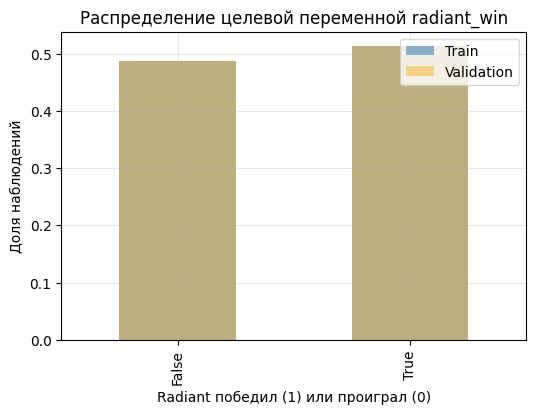

In [52]:
fig, ax = plt.subplots(figsize=(6,4))

train_df['radiant_win'].value_counts(normalize=True).sort_index().plot(
    kind='bar',
    alpha=0.6,
    color='steelblue',
    label='Train',
    ax=ax
)

val_df['radiant_win'].value_counts(normalize=True).sort_index().plot(
    kind='bar',
    alpha=0.4,
    color='orange',
    label='Validation',
    ax=ax
)

plt.title('Распределение целевой переменной radiant_win')
plt.xlabel('Radiant победил (1) или проиграл (0)')
plt.ylabel('Доля наблюдений')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [53]:
print("Train:")
print(train_df['radiant_win'].value_counts(normalize=True))
print("\nValidation:")
print(val_df['radiant_win'].value_counts(normalize=True))


Train:
radiant_win
True     0.512532
False    0.487468
Name: proportion, dtype: float64

Validation:
radiant_win
True     0.512441
False    0.487559
Name: proportion, dtype: float64


сбаллансированно

так как целевая переменная radiant_win бинарная, метрика Gini является подходящей и корректной для оценки качества модели в данной задаче. Gini подходит, так как важен порядок предсказанных вероятностей.

#### Задание 1.2. Бейзлайн (0.5 балла)

На сей раз мы будем решать задачу классификации, поэтому нам понадобится соответствующая модель. В целом, наши данные уже содержат признаки, по которым что-то даже можно построить.

1. Выберите один или несколько признаков, по которым планируете предсказывать целевую переменную (здесь не нужно придумывать ничего адового, можете даже не делать никаких трансформов, ими мы займемся позже).
2. Выберите модель по вашему вкусу, главное, чтобы она была из `sklearn.linear_model` и не была перцептроном. **Любые другие модели, кроме линейных, запрещены!!!**
3. Обучите модель и замерьте качество.

In [54]:
# ヾ(⌐■_■)ノ♪ your code here

(', '.join(match_features_train.columns.tolist()))

'match_id, date, region, game_mode, duration, radiant_win, kills_mean, kills_sum, kills_max, kills_min, kills_std, kills_count, deaths_mean, deaths_sum, deaths_max, deaths_min, deaths_std, deaths_count, assists_mean, assists_sum, assists_max, assists_min, assists_std, gold_per_min_mean, gold_per_min_sum, gold_per_min_max, gold_per_min_min, gold_per_min_std, gold_per_min_median, xp_per_min_mean, xp_per_min_sum, xp_per_min_max, xp_per_min_min, xp_per_min_std, xp_per_min_median, radiant_gold_adv_final, radiant_gold_adv_mean, radiant_gold_adv_max, radiant_exp_adv_final, radiant_exp_adv_mean, radiant_exp_adv_max'

выберем колоник, которые по смыслу могут влиять на победу :

In [58]:
features = [
    'kills_mean',
    'deaths_mean',
    'assists_mean',
    'gold_per_min_mean',
    'xp_per_min_mean',
    'radiant_gold_adv_final',
    'radiant_exp_adv_final', 
    'duration',
    'game_mode'
]


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X_train = train_df[features].fillna(train_df[features].mean())
y_train = train_df['radiant_win']

X_val = val_df[features].fillna(train_df[features].mean())
y_val = val_df['radiant_win']

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

acc = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print(f"Gini:     {2*auc - 1:.4f}")


Accuracy: 0.5815
ROC-AUC:  0.6246
Gini:     0.2492


### **Задание 2. Оптимизация для уже смешариков (2 балла)** <img align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

#### Задание 2.1. Optuna для самых маленьких (0.75 балл)

**NB: Хотя это задание и опциональное, выполнить его настоятельно рекомендуется, оно будет очень полезно сейчас, в этой дз, и вообще!**

Не стоит забывать, что у любой модели есть гиперпараметры. Конечно, львиная доля качества будет идти от фичей, но гиперпараметры списывать со счетов тоже не стоит. В конце концов, может быть, что с набором фичей, который считался безперспективным, оптимизированная модель покажет лушее качество, чем модель на топовых фичах, вот и посмотрим.

Оптимизация моделей с большим числом гиперпараметров это сложное дело. Нетрудно догадаться, что в случае, когда параметров $m$, сложность перебора в самом худшем случае будет порядка $n^m$. Подумаем, как это делать умнее.

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. В этом задании предлагается познакомиться с библиотекой [optuna](https://optuna.org/), которая делает перебор гиперпараметров легким и приятным, а также сохраняет всю историю экспериментов в одно место за вас.

Будем разбираться с этим поэтапно.

1. Напишите функцию оптимизации для логистической регрессии. Можете воспользоваться шаблоном ниже, хотя, конечно, это необязательно.
2. Подберите хотя бы 2 гиперпараметра для выбранной вами модели.

In [68]:
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [69]:
def objective(trial):

    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    
    if solver in ['lbfgs'] and penalty == 'l1':
        raise optuna.TrialPruned()

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            max_iter=2000,
            random_state=42
        )
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    gini_valid = 2 * auc - 1

    return gini_valid

In [66]:
study = optuna.create_study(direction='maximize', study_name="LogReg_Optimization")
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2025-11-08 17:08:20,403] A new study created in memory with name: LogReg_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-08 17:08:24,349] Trial 0 finished with value: 0.2491661950395232 and parameters: {'C': 0.6937314745112971, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.2491661950395232.
[I 2025-11-08 17:08:24,803] Trial 1 finished with value: 0.24914456863309642 and parameters: {'C': 0.08803938120297293, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.2491661950395232.
[I 2025-11-08 17:08:25,343] Trial 2 finished with value: 0.2491834676519591 and parameters: {'C': 0.03648019869690532, 'solver': 'liblinear', 'penalty': 'l2'}. Best is trial 2 with value: 0.2491834676519591.
[I 2025-11-08 17:08:25,884] Trial 3 finished with value: 0.24916326728125737 and parameters: {'C': 8.862661284674775, 'solver': 'liblinear', 'penalty': 'l2'}. Best is trial 2 with value: 0.2491834676519591.
[I 2025-11-08 17:08:28,714] Trial 4 finished with value: 0.24915696645393504 and parameters: {'C': 0.007347549341599388, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 2 with 

In [67]:
print("Лучшие параметры:")
print(study.best_params)

print(f"Лучший Gini: {study.best_value:.4f}")


Лучшие параметры:
{'C': 0.004742081563551875, 'solver': 'liblinear', 'penalty': 'l2'}
Лучший Gini: 0.2492


результат не хуже, чем был

Убедитесь, что ваша функция работает и модель как минимум работает не хуже, чем без всякого перебора параметров. Качество может вырасти, но очень незначительно, поскольку мы все еще работаем с бейзлайном.

#### Задание 2.2. Логирование в optuna (0.75 балла)

Оптуна - это великая библиотека еще и потому, что сразу предлагает удобный инструментарий для логирования экспериментов.

Посмотрите, как в `optuna` устроена запись в хранилища, и добавьте это в пайплайн оптимизации. Без указания БД все запуски оптуны сотрутся, как только закончится сессия. Более того, так можно распараллелить процесс оптимизации на несколько машин.

Что от вас требуется:
- отдельный `storage`, который сохраняет результаты локально, а не только в рамках одной сессии. В любом удобном для вас виде: хоть датафрейм, хоть БД (в `optuna` для этого есть специальный класс, поищите).
- логирование разных экспериментов с разным именем, чтобы иметь возможность их сравнивать (например, `linreg_base` для бейзлайна регрессии, `logreg_yoba_features_ultrafinal` для самого лучшего логрега, главное, чтобы вам это было понятно и можно было адекватно сравнить перформанс разных моделей, ничего не потеряв).

In [ ]:
storage = optuna.storages.RDBStorage(
    url="sqlite:///optuna_tests.db"  
)

In [71]:
study = optuna.create_study(
    study_name="logreg_baseline",
    direction="maximize",
    storage=storage,
    load_if_exists=True 
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Лучшие параметры:")
print(study.best_params)
print(f"Лучший Gini: {study.best_value:.4f}")


[I 2025-11-08 17:19:21,901] A new study created in RDB with name: logreg_baseline


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-08 17:19:25,245] Trial 0 finished with value: 0.2492745853679339 and parameters: {'C': 0.012503561626535356, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.2492745853679339.
[I 2025-11-08 17:19:31,770] Trial 1 finished with value: 0.2490145543010147 and parameters: {'C': 0.006106017697773477, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 0 with value: 0.2492745853679339.
[I 2025-11-08 17:19:32,233] Trial 2 finished with value: 0.24913725864822656 and parameters: {'C': 0.46235821877426714, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.2492745853679339.
[I 2025-11-08 17:19:36,304] Trial 3 finished with value: 0.24916532804504277 and parameters: {'C': 0.19123985754054612, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 0 with value: 0.2492745853679339.
[I 2025-11-08 17:19:36,748] Trial 4 finished with value: 0.24916042201761646 and parameters: {'C': 0.030206772868760313, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with

In [ ]:
import datetime

# Настройка хранилища
storage = optuna.storages.RDBStorage(
    url="sqlite:///optuna_tests.db"
)

# Создание study
study = optuna.create_study(
    study_name="logreg_baseline",
    direction="maximize",
    storage=storage,
    load_if_exists=True
)

# Оптимизация
start = datetime.datetime.now()
study.optimize(objective, n_trials=30, show_progress_bar=True)
end = datetime.datetime.now()

# Лог результатов
print(f"\nОптимизация завершена за {end - start}")
print("Лучшие параметры:")
print(study.best_params)
print(f"Лучший Gini: {study.best_value:.4f}")

# Сохранение результатов
df_trials = study.trials_dataframe()
df_trials.to_csv("optuna_logreg_trials.csv", index=False)


[I 2025-11-08 17:26:47,763] A new study created in RDB with name: logreg_baseline


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-08 17:26:50,244] Trial 0 finished with value: 0.24864387071084937 and parameters: {'C': 0.001840168230066852, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.24864387071084937.
[I 2025-11-08 17:26:50,717] Trial 1 finished with value: 0.24918657641784892 and parameters: {'C': 0.00216993501113407, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 1 with value: 0.24918657641784892.
[I 2025-11-08 17:26:54,835] Trial 2 finished with value: 0.2491667060256466 and parameters: {'C': 0.6511498605668439, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.24918657641784892.
[I 2025-11-08 17:26:54,858] Trial 3 pruned. 
[I 2025-11-08 17:26:59,092] Trial 4 finished with value: 0.24916862903141745 and parameters: {'C': 0.47824286470631705, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.24918657641784892.
[I 2025-11-08 17:26:59,688] Trial 5 finished with value: 0.24917099774843887 and parameters: {'C': 0.10339280155573213, 'solver': 'libl

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

#### Задание 2.3. Базовый feature selection (0.5 балла)

У любой модели, помимо этапа тюнинга во время обучения, зачастую есть и тюнинг после обучения. Готовы поспорить, что из сотен признаков, что вы потенциально можете нагенерить в данном задании, большинство окажутся вовсе бесполезными. Подробнее с методами feature selection мы познакомимся позже, но уже сейчас мы можем воспользоваться знанием, что к примеру L1-регуляризация может занулять ненужные веса, и что коэффициент у нормированных весов отражает, насколько этот вес важен.

Попробуйте встроить примитивный алгоритм feature selection:
- после обучения модели будем проверять по фиксированной сетке [25%, 50%, 75%, 100%], сколько фичей хотим оставить;
- для каждого значения сетки замеряем качество алгоритма и логгируем в оптуну значение метрики для данного процента фичей;
- для выбора оптимальной модели храним не самое лучшее значение Джини, а самое лучшее значение с учетом оставшегося количества признаков.

In [75]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


def gini(y_true, y_score):
    """Рассчитывает коэффициент Gini на основе roc_auc."""
    return abs(2 * roc_auc_score(y_true, y_score) - 1.0)

def build_objective_with_fs(X, y, perc_grid=(0.25, 0.50, 0.75, 1.00), n_splits=5, alpha=0.01):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    feature_names = np.array(X.columns)

    def objective(trial):
        rank_solver = trial.suggest_categorical("rank_solver", ["liblinear", "saga"])
        rank_C = trial.suggest_float("rank_C", 1e-3, 10.0, log=True)

        rank_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l1",
                solver=rank_solver,
                C=rank_C,
                max_iter=2000,
                random_state=42
            ))
        ])

        rank_pipe.fit(X, y)
        coefs = rank_pipe.named_steps["model"].coef_.ravel()
        abs_importance = np.abs(coefs)
        if not np.any(abs_importance):
            abs_importance = np.ones_like(abs_importance)

        best_gini = -np.inf
        best_reg_score = -np.inf
        best_pct = None
        best_kept_names = None

        for pct in perc_grid:
            k = max(1, int(np.ceil(len(feature_names) * pct)))
            top_idx = np.argsort(-abs_importance)[:k]
            kept_names = feature_names[top_idx]

            eval_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    penalty="l2",
                    solver="lbfgs",
                    C=1.0,
                    max_iter=2000,
                    random_state=42
                ))
            ])

            y_proba = cross_val_predict(
                eval_pipe, X[kept_names], y, cv=cv, method="predict_proba", n_jobs=-1
            )[:, 1]
            g = gini(y, y_proba)

            reg_score = g - alpha * (k / len(feature_names))
            trial.set_user_attr(f"gini@{int(pct*100)}%", g)
            trial.set_user_attr(f"kept_features@{int(pct*100)}%", list(kept_names))

            if reg_score > best_reg_score:
                best_reg_score = reg_score
                best_gini = g
                best_pct = pct
                best_kept_names = list(kept_names)

        trial.set_user_attr("best_pct", best_pct)
        trial.set_user_attr("best_gini_raw", best_gini)
        trial.set_user_attr("best_kept_features", best_kept_names)

        return best_reg_score

    return objective


In [76]:
objective = build_objective_with_fs(X_train, y_train)

In [78]:
storage = optuna.storages.RDBStorage(url="sqlite:///optuna_tests.db")

study_fs = optuna.create_study(
    study_name="logreg_feature_selection_basic",
    direction="maximize",
    storage=storage,
    load_if_exists=True
)

study_fs.optimize(objective, n_trials=10, show_progress_bar=True)


[I 2025-11-08 17:36:24,657] Using an existing study with name 'logreg_feature_selection_basic' instead of creating a new one.


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-08 17:36:44,984] Trial 1 finished with value: 0.2390059799638774 and parameters: {'rank_solver': 'liblinear', 'rank_C': 0.025010772632967148}. Best is trial 1 with value: 0.2390059799638774.
[I 2025-11-08 17:36:56,896] Trial 2 finished with value: 0.2390059799638774 and parameters: {'rank_solver': 'saga', 'rank_C': 1.349511667553033}. Best is trial 1 with value: 0.2390059799638774.
[I 2025-11-08 17:37:15,613] Trial 3 finished with value: 0.2390059799638774 and parameters: {'rank_solver': 'liblinear', 'rank_C': 0.16951098462403016}. Best is trial 1 with value: 0.2390059799638774.
[I 2025-11-08 17:37:32,657] Trial 4 finished with value: 0.2390059799638774 and parameters: {'rank_solver': 'liblinear', 'rank_C': 6.946165580332851}. Best is trial 1 with value: 0.2390059799638774.
[I 2025-11-08 17:37:44,464] Trial 5 finished with value: 0.2390059799638774 and parameters: {'rank_solver': 'saga', 'rank_C': 0.5946357773989579}. Best is trial 1 with value: 0.2390059799638774.
[I 2025-1

In [79]:
print("Лучшее значение регуляризованного Gini:", study_fs.best_value)
print("Лучшие гиперпараметры:", study_fs.best_trial.params)
print("Оптимальная доля признаков:", study_fs.best_trial.user_attrs.get("best_pct"))
print("Лучший «сырой» Gini:", study_fs.best_trial.user_attrs.get("best_gini_raw"))

top_features = study_fs.best_trial.user_attrs.get("best_kept_features")
print("Топ признаков:", top_features[:10], "...")


Лучшее значение регуляризованного Gini: 0.24113470878150498
Лучшие гиперпараметры: {'rank_solver': 'liblinear', 'rank_C': 0.002810541897011358}
Оптимальная доля признаков: 0.5
Лучший «сырой» Gini: 0.24669026433706054
Топ признаков: ['radiant_gold_adv_final', 'radiant_exp_adv_final', 'duration', 'gold_per_min_mean', 'kills_mean'] ...


Регуляризованный Gini штрафует за число признаков. произошла потеря около 1% качества при сохранении лишь 50% признаков. так что меньшее значение Gini логично. при потере точности выигрываем в интерпретируемости и устойчивости модели. модель стала менее переобученой.

Далее вы можете либо тестить фичи на дефолтной модели, либо тюнить ее после каждого изменения. Выбор, как обычно, за вами.

### **Задание 3. Простейший EDA (2.5 балла)** <img height=40px src="https://cdn3.emoji.gg/emojis/136857-pepesmoke.gif">

Чтобы построить реально балдежную модель, зачастую не получится просто жахнуть фит предиктов и пойти пить смузи, пока параметры крутятся сами. Неет, зачастую для этого требуется долгая и утомительная возня с графиками. А если необходима еще и отчетность, то и без графиков совсем не обойтись. Так и у нас. Конечно, никаких экстремальных признаков наш датасет не содержит, но и того, что есть, хватит, чтобы продемонстрировать темную сторону любого Data Science.

Задания ниже призваны скорее познакомить вас с данными, а заодно показать несколько простых способов анализировать данные, которые, в целом, никогда не помешают при работе с любыми признаками, хотя обычно так подробно смотрят лишь на самые потенциально важные факторы.

В заданиях пункта 3 всегда требуется:
- аргументировать, почему вы делаете такое решение;
- обучить модель по итогам выполнения пункта;
- сделать вывод, зашел признак или нет, и ваше мнение, почему так получилось.

#### Задание 3.1. Пропуски в данных (0.5 балла)

В реальной жизни все обычно гораздо хуже, чем в вылизанных датасетах, и наши данные, увы не исключение. Колонка `duration`, которую вы могли использовать, а могли и не использовать для обучения, доступна лишь на обучающих данных, но не на тестовых. Если вы хотите опираться на длительность матча для предсказания победы, сперва эту длительность необходимо как-то достать.

У вас есть несколько возможностей это сделать:

1. Заполнить пропуски на валидационной и тестовой выборках константным значением.
2. Попробовать предсказать значение `duration` при помощи простенькой линейной модели.
3. Добавить отсутствие значения отдельным признаком.

Задание заключается в следующем:

1. Посмотрите на распределение `duration`, подберите визуализацию, которая покажет это наиболее наглядно.
2. Сделайте вывод о том, какое из выше представленных решений лучше всего поможет.
3. Заполните пропуски.

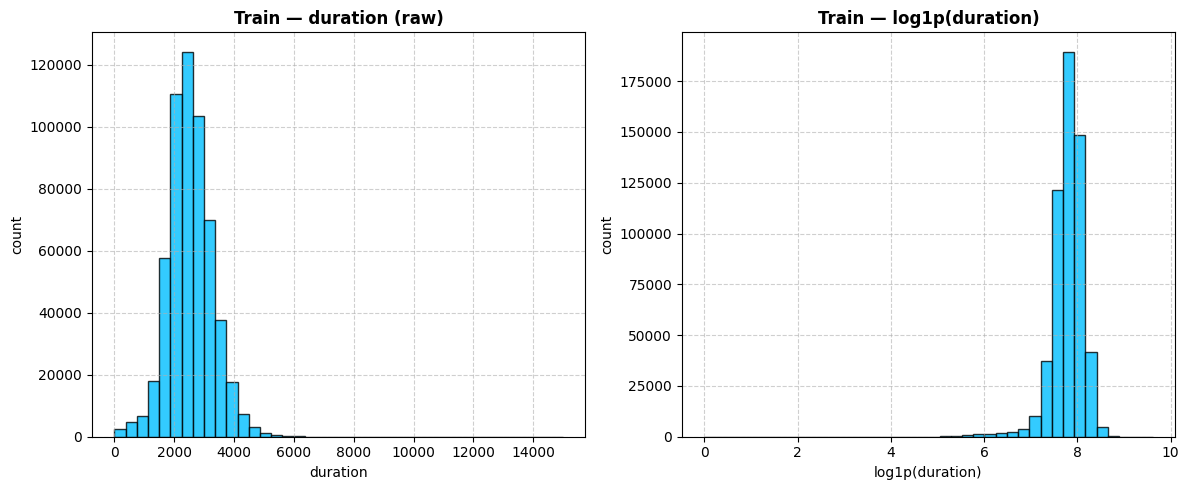

In [90]:
def plot_duration_distribution(df, title):
    d = df["duration"].dropna()
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    axs[0].hist(d, bins=40, alpha=0.8, color="deepskyblue", edgecolor="black")
    axs[0].set_title(f"{title} — duration (raw)", fontsize=12, weight="bold")
    axs[0].set_xlabel("duration")
    axs[0].set_ylabel("count")
    axs[0].grid(True, linestyle="--", alpha=0.6)

    axs[1].hist(np.log1p(d), bins=40, alpha=0.8, color="deepskyblue", edgecolor="black")
    axs[1].set_title(f"{title} — log1p(duration)", fontsize=12, weight="bold")
    axs[1].set_xlabel("log1p(duration)")
    axs[1].set_ylabel("count")
    axs[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_duration_distribution(train_df, "Train")


- duration (raw): значения сильно скошены вправо
- Логарифмированное распределение ближе к нормальному: колокол посередине, хвосты укорочены. лучше использовать его

In [91]:
train_df['duration'].isna().mean() * 100

np.float64(0.0)

пропусков нет

#### Задание 3.2. Простейшие преобразования (0.5 балла)

В жизни рядового датасаентиста часто возникает такая ситуация, что фича, которая ну должна быть клевой, на практике оказывается тем еще отстоем. Причин тому может быть несколько: признак действительно может быть нерелевантным, в данных банально может быть ошибка; либо же мы просто неправильно этот признак готовим. Народная мудрсть (и душнилы-математики) гласит, что признаки желательно подбирать из нормального распределения в случае L2-регуляризации, тогда как на практике это достигается ой как не всегда.

Сделаем следующее:

1. Посмотрите на гистограмму признака `duration`, если вы не сделали этого до. Что вы можете сказать про смещение, среднее, хвосты распределения этого признака?
2. Изучите три распространенных способа сделать признак $y$ ($y$ здесь и ниже это `duration`, не таргет) чуть более нормальным:

$$y \rightarrow \log y,  \sqrt{y}, \frac{1}{y}$$

Посмотрите, что происходит с распределением, если применить каждое из них.

3. Попробуйте добавить все три вышеперечисленных трансформации, вместе с признаком $\exp{\log{y}}$ (это снова `duration`).

1. гистограммы были построены в предыдущем пункте. распределение сильно смещено вправо. среднее больше чем медиана. есть тяженый хвост, то есть редкие, но длинные игры. это нормально, так как по уловию игра может длиться от 0 минут до бесконечности, и аномально длительные игры могут втсречаться в данных. 

2. 

In [98]:
train_df['duration'].max()

np.int64(14979)

In [100]:
train_df['duration'].mean()

np.float64(2536.6606929404525)

In [99]:
train_df['duration'].min()

np.int64(0)

In [ ]:
def add_transformations(df, column="duration"):
    df = df.copy()
    if column not in df.columns:
        raise KeyError(f"Колонка '{column}' не найдена в датафрейме.")
    
    df[f"{column}_log"] = np.log1p(df[column])
    df[f"{column}_sqrt"] = np.sqrt(df[column])
    df[f"{column}_inv"] = 1 / (df[column] + 1e-6)
    return df


def plot_transformations(df, column="duration"):
    transformations = [f"{column}_log", f"{column}_sqrt", f"{column}_inv"]
    titles = ["log(duration)", "sqrt(duration)", "1/duration"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in zip(axs, transformations, titles):
        ax.hist(df[col].dropna(), bins=40, color="blue", alpha=0.7, edgecolor="black")
        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

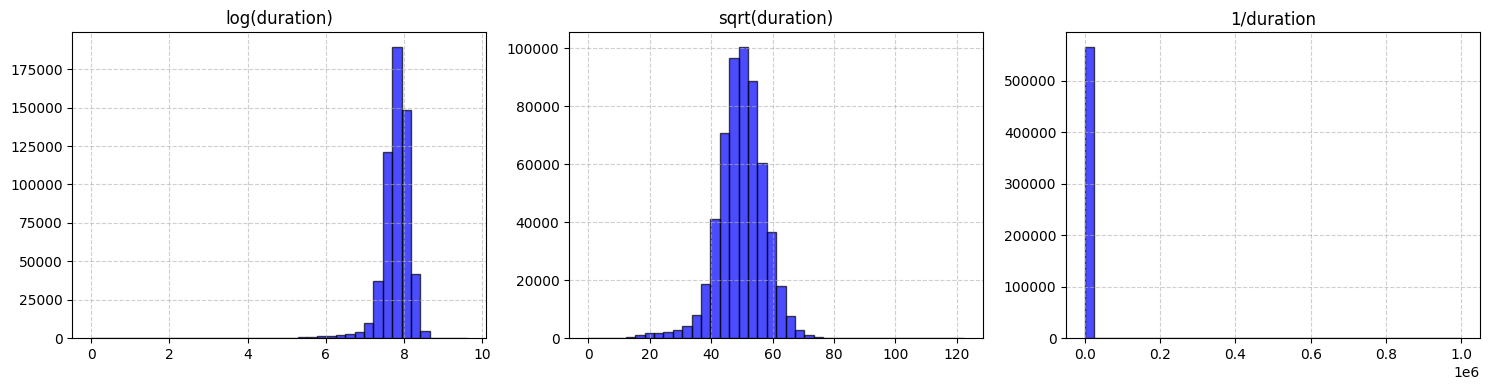

In [94]:
train_df = add_transformations(train_df, "duration")
plot_transformations(train_df, "duration")

- log(duration): распределение стало почти симметричным, близким к нормальному, длинный правый хвост исчез
- sqrt(duration): также сгладило асимметрию, но не так сильно, как логарифм
- 1/duration: почти все значения сосредоточились около нуля, так как значения duration очень большие (среднее- 2536.66), и деление на единицу приводит к появлению очень маленьких значений. признак неинформативен.

3.

In [103]:
def add_transformations(df, column="duration"):
    df = df.copy()
    if column not in df.columns:
        raise KeyError(f"Колонка '{column}' не найдена в датафрейме.")
    
    df[f"{column}_log"] = np.log1p(df[column])
    df[f"{column}_sqrt"] = np.sqrt(df[column])
    df[f"{column}_inv"] = 1 / (df[column] + 1e-6)
    df[f"{column}_exp_log"] = np.expm1(df[f"{column}_log"])  # обратное преобразование
    return df

In [104]:
train_df = add_transformations(train_df, "duration")

In [105]:
diff = np.abs(train_df["duration"] - train_df["duration_exp_log"]).mean()
print(f"Среднее отклонение между duration и exp(log(duration)): {diff:.6f}")

Среднее отклонение между duration и exp(log(duration)): 0.000000


получили тот же самы признак, без отклонений.

#### Задание 3.3. Регионы (0.5 балла)

Не секрет, что в отдельных регионах уровень скилла игроков отличается в лучшую или худшую сторону. Даже простые, казалось бы, признаки, иногда оказываются полезными, если распределения таргета на них по какой-то причине отличаются друг от друга.

Ваша задача:

1. Построить распределение категорий признака `region` на графике.
2. Проверить, отличается ли распределение целевой переменной для разных категорий `region`.
3. Закодируйте признак (как именно - на ваше усмотрение, но вам может очень понравиться вот [эта](https://contrib.scikit-learn.org/category_encoders) библиотека).

1. распределение region

In [107]:
train_df['region'].unique()

array([ 3,  4,  6, 12, 10, 11,  2,  9,  5,  1,  7,  8])

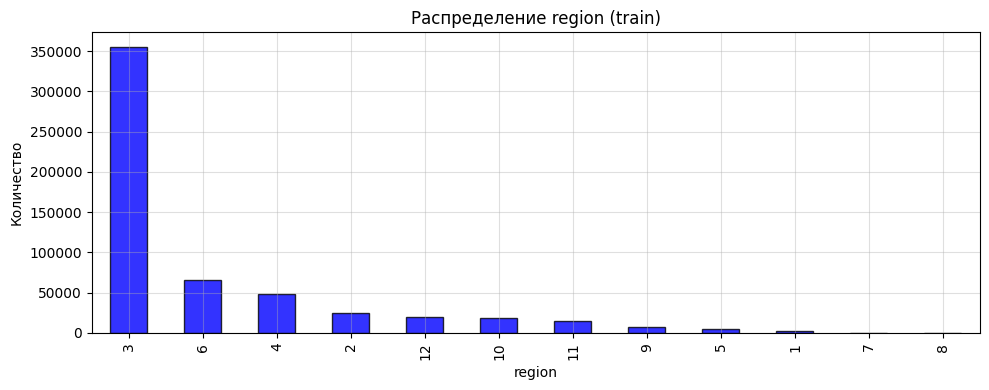

In [106]:
region_counts = train_df['region'].value_counts(dropna=False).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
region_counts.plot(kind='bar', ax=ax, color='blue', edgecolor='black', alpha=0.8)
ax.set_title('Распределение region (train)')
ax.set_ylabel('Количество')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

2.

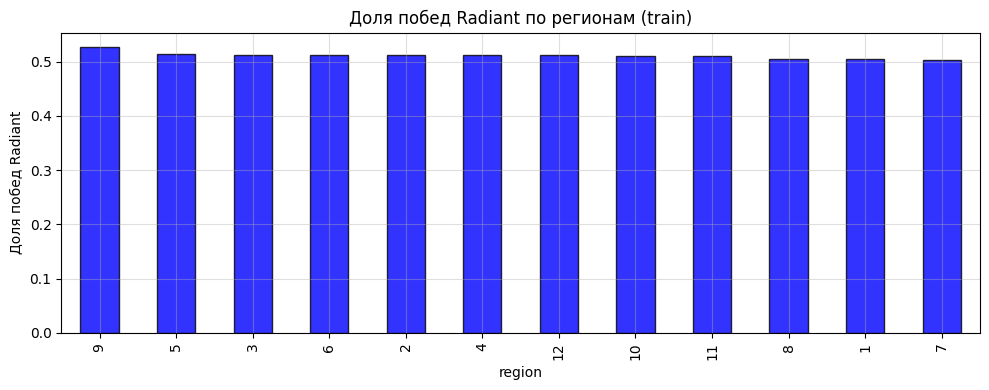

In [108]:
win_rate_by_region = (
    train_df.groupby('region')['radiant_win']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
win_rate_by_region.plot(kind='bar', ax=ax, color='blue', edgecolor='black', alpha=0.8)
ax.set_title('Доля побед Radiant по регионам (train)')
ax.set_ylabel('Доля побед Radiant')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

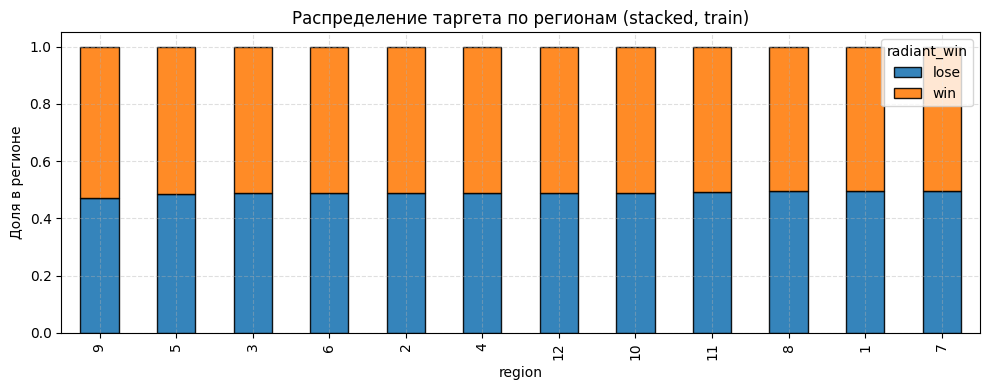

In [110]:
ct = (
    pd.crosstab(train_df['region'], train_df['radiant_win'], normalize='index')
    .rename(columns={0: 'lose', 1: 'win'})
    .sort_values('win', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ct[['lose', 'win']].plot(kind='bar', stacked=True, ax=ax, edgecolor='black', alpha=0.9)
ax.set_title('Распределение таргета по регионам (stacked, train)')
ax.set_ylabel('Доля в регионе')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


распределение почти идеально равномерное

3. 

используем one-hot-encoding

In [111]:
cats = pd.get_dummies(train_df['region'], prefix='region')

train_df_ohe = pd.concat([train_df.drop(columns=['region']), cats], axis=1)

val_cats = pd.get_dummies(val_df['region'], prefix='region')
val_df_ohe = pd.concat([val_df.drop(columns=['region']), val_cats], axis=1)
val_df_ohe = val_df_ohe.reindex(columns=train_df_ohe.columns, fill_value=0)

test_cats = pd.get_dummies(match_features_test['region'], prefix='region')
test_df_ohe = pd.concat([match_features_test.drop(columns=['region']), test_cats], axis=1)
test_df_ohe = test_df_ohe.reindex(columns=train_df_ohe.columns, fill_value=0)

In [114]:
pd.concat(
    [train_df[['region']], 
     train_df_ohe[[col for col in train_df_ohe.columns if col.startswith("region_")]]],
    axis=1
).head(10)

,region,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10,region_11,region_12
223493,3,False,False,True,False,False,False,False,False,False,False,False,False
237306,4,False,False,False,True,False,False,False,False,False,False,False,False
32419,3,False,False,True,False,False,False,False,False,False,False,False,False
252144,6,False,False,False,False,False,True,False,False,False,False,False,False
27096,3,False,False,True,False,False,False,False,False,False,False,False,False
422939,3,False,False,True,False,False,False,False,False,False,False,False,False
213608,6,False,False,False,False,False,True,False,False,False,False,False,False
523843,3,False,False,True,False,False,False,False,False,False,False,False,False
295344,3,False,False,True,False,False,False,False,False,False,False,False,False
433896,6,False,False,False,False,False,True,False,False,False,False,False,False


закодировано правильно

#### Задание 3.4. Даты (0.5 балла)

Бывалые игроки в доту знают, что игра постоянно (хотя это спорно) обновляется - в ней появляются новые механики, меняются старые и так далее. Разумно предположить, что со временем модель может вести себя чуточку по-другому. С временными изменениями часто помогает отслеживать изменение временных же признаков

Требуется:

1. Посмотреть, какие временные признаки можно достать, зная дату проведения матча
2. Подумать, есть ли какие-то знаменательные даты, которые могли повлиять на результаты матча (скажем, в одни дни игроки чуть более поддатые, или наоборот, в общем подумайте!)
2. Подумать, как именно вы хотите их кодировать (как числовые, категориальные, етц)
3. Вытащите хотя бы 2 разных временных признака из колонки `date`, добавьте хотя бы один флаг (признак со значением 1 или 0) для знаменательной даты

In [115]:
train_df.head()

,match_id,date,region,game_mode,duration,radiant_win,kills_mean,kills_sum,kills_max,kills_min,kills_std,kills_count,deaths_mean,deaths_sum,deaths_max,deaths_min,deaths_std,deaths_count,assists_mean,assists_sum,assists_max,assists_min,assists_std,gold_per_min_mean,gold_per_min_sum,gold_per_min_max,gold_per_min_min,gold_per_min_std,gold_per_min_median,xp_per_min_mean,xp_per_min_sum,xp_per_min_max,xp_per_min_min,xp_per_min_std,xp_per_min_median,radiant_gold_adv_final,radiant_gold_adv_mean,radiant_gold_adv_max,radiant_exp_adv_final,radiant_exp_adv_mean,radiant_exp_adv_max,duration_log,duration_sqrt,duration_inv,duration_inv_scaled,duration_exp_log
223493,1473416099,2024-04-16,3,5,2080,True,9.2,92.0,19.0,2.0,4.541170,10,9.5,95.0,13.0,5.0,2.953341,10,16.1,161.0,28.0,9.0,5.820462,384.2,3842.0,599.0,182.0,118.744169,386.0,488.7,4887.0,763.0,229.0,168.058224,464.0,NaN,NaN,NaN,NaN,NaN,NaN,7.640604,45.607017,0.000481,0.480769,2080.0
237306,1456262202,2024-04-22,4,2,3148,True,9.1,91.0,16.0,3.0,4.794673,10,9.6,96.0,12.0,7.0,1.349897,10,15.7,157.0,25.0,4.0,6.976946,415.5,4155.0,664.0,242.0,129.124617,393.5,515.3,5153.0,625.0,293.0,130.492273,593.0,NaN,NaN,NaN,NaN,NaN,NaN,8.054840,56.107041,0.000318,0.317662,3148.0
32419,1507155093,2024-01-16,3,1,2473,False,6.8,68.0,17.0,2.0,5.159673,10,7.2,72.0,13.0,3.0,3.293090,10,9.8,98.0,17.0,3.0,4.077036,451.0,4510.0,717.0,290.0,148.434797,404.0,487.0,4870.0,824.0,226.0,178.103590,457.0,-5497.0,-1155.125,33.0,-1295.0,414.7500,1217.0,7.813592,49.729267,0.000404,0.404367,2473.0
252144,1594311647,2024-04-29,6,1,3157,True,9.9,99.0,20.0,2.0,6.640783,10,9.9,99.0,15.0,6.0,2.685351,10,16.0,160.0,25.0,5.0,6.480741,450.9,4509.0,708.0,211.0,163.169612,465.5,481.4,4814.0,626.0,200.0,161.821713,534.0,881.0,377.500,1039.0,3515.0,1961.5625,3515.0,8.057694,56.187187,0.000317,0.316756,3157.0
27096,1563233586,2024-01-13,3,1,3397,False,10.8,108.0,17.0,5.0,4.984420,10,11.4,114.0,15.0,9.0,2.011080,10,20.5,205.0,29.0,13.0,5.082650,439.4,4394.0,600.0,309.0,109.229829,434.0,509.3,5093.0,602.0,345.0,87.149998,549.0,-2514.0,-343.250,343.0,-2173.0,-284.3125,239.0,8.130942,58.283788,0.000294,0.294377,3397.0


игроки, скорей всего, больше играют по выходным и в праздничные дни.

из колонки date с помощью datetime можно вытащить год, месяц, день, день недели, и был ли это выходной день. еще используем библиотеку holidays, чтобы определить какие дни были праздничные

In [125]:
import holidays

def add_date_features(df, date_col="date", country="US"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    holiday_dates = holidays.CountryHoliday(country, years=range(df[date_col].dt.year.min(),
                                                                 df[date_col].dt.year.max()+1))
    df["year"]       = df[date_col].dt.year
    df["month"]      = df[date_col].dt.month
    df["day"]        = df[date_col].dt.day
    df["weekday"]    = df[date_col].dt.weekday
    df["hour"]       = df[date_col].dt.hour
    df["is_weekend"] = df["weekday"].isin([5,6]).astype(int)
    df["is_holiday"] = df[date_col].isin(holiday_dates).astype(int)
    return df



In [123]:
train_df = add_date_features(train_df, "date")
train_df[["date", "year", "month", "weekday", "is_weekend", "is_holiday"]].head()

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_5148/4247931664.py:14: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df[date_col].isin(holiday_dates).astype(int)


,date,year,month,weekday,is_weekend,is_holiday
223493,2024-04-16,2024,4,1,0,0
237306,2024-04-22,2024,4,0,0,0
32419,2024-01-16,2024,1,1,0,0
252144,2024-04-29,2024,4,0,0,0
27096,2024-01-13,2024,1,5,1,0


In [124]:
print(train_df['weekday'].unique())
print(train_df['month'].unique())
print(train_df['year'].unique())
print(train_df['is_holiday'].unique())

[1 0 5 4 3 2 6]
[ 4  1  7  9  5  6 10  8 11  3  2 12]
[2024]
[0 1]


кодировка сработала правильно

#### Задание 3.5. Бинаризация (0.5 балла)

В нашем мире бывает так, что один отдельный признак оказывается настолько важен, или настолько сложен, что одним весом в линейной регрессии его ну никак не описать. Тогда на помощь часто приходит бинаризация. Ее суть заключается в том, что все распределение признака бьется на непересекающиеся бины и каждый из них уже можно закодировать, например, отдельной категорией бина. Попробуем?

Сделайте следующее:

1. Возьмите признак, который, как вам кажется, может быть хорошей целью для бинаризации. Это может быть что угодно до тех пор, пока признак вещественный.
2. Бинаризуйте признак произвольным способом (равномерная сетка, квантильная сетка, ...).
3. Проверьте, зашло там или нет.

исследуем признак duration

In [ ]:
def binarize_feature(df, column="duration", n_bins=7, strategy="quantile"):
    df = df.copy()
    
    if strategy == "uniform":
        df[f"{column}_bin"] = pd.cut(df[column], bins=n_bins, labels=False)
    elif strategy == "quantile":
        df[f"{column}_bin"] = pd.qcut(df[column], q=n_bins, labels=False, duplicates="drop")
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")
    
    return df

In [129]:
train_df_binned = binarize_feature(train_df, column="duration", n_bins=5, strategy="quantile")
train_df_binned[[ "duration", "duration_bin" ]].head(10)

,duration,duration_bin
223493,2080,1
237306,3148,4
32419,2473,2
252144,3157,4
27096,3397,4
422939,3487,4
213608,2759,3
523843,3318,4
295344,1996,1
433896,1839,0


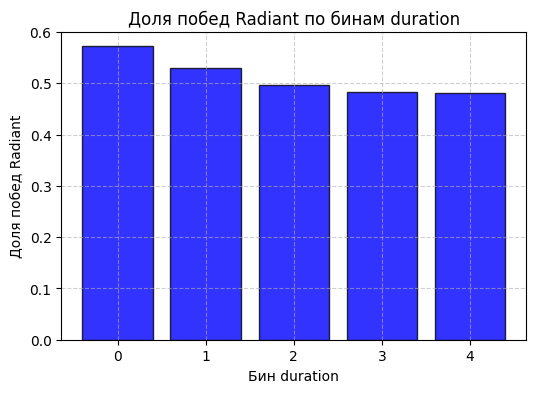

In [130]:
bin_winrate = (
    train_df_binned.groupby("duration_bin")["radiant_win"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(bin_winrate["duration_bin"], bin_winrate["radiant_win"], color="blue", edgecolor="black", alpha=0.8)
plt.title("Доля побед Radiant по бинам duration")
plt.xlabel("Бин duration")
plt.ylabel("Доля побед Radiant")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

замерим качество на меодели

In [ ]:
import category_encoders as ce


def gini_score(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1

for df in [train_df, val_df]:
    df["weekday"] = pd.to_datetime(df["date"], errors="coerce").dt.weekday
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

for df in [train_df, val_df]:
    df["duration_bin"] = pd.qcut(df["duration"], q=5, labels=False, duplicates="drop")

cat_features = ["region", "weekday"]
encoder = ce.TargetEncoder(cols=cat_features, smoothing=0.5)
encoder.fit(train_df[cat_features], train_df["radiant_win"])

train_encoded = train_df.copy()
val_encoded = val_df.copy()

train_encoded[cat_features] = encoder.transform(train_df[cat_features])
val_encoded[cat_features] = encoder.transform(val_df[cat_features])

features_extended = features + ["duration_bin", "region", "weekday", "is_weekend"]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2500, C=0.7, solver="lbfgs", random_state=42))
])

X_train = train_encoded[features_extended]
y_train = train_encoded["radiant_win"]
X_val = val_encoded[features_extended]
y_val = val_encoded["radiant_win"]

pipe.fit(X_train, y_train)
y_proba = pipe.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_proba)
gini = gini_score(y_val, y_proba)

print("Результаты модели после улучшения:")
print(f"ROC-AUC: {auc:.4f}")
print(f"Gini:    {gini:.4f}")

Результаты модели после улучшения:
ROC-AUC: 0.6256
Gini:    0.2512


качество немного улучшилось. преобразования положительно влияют на результат.

### **Задание 4. Эмбеддинги** (2 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее. Делать мы это будем при помощи эмбеддингов. Это не самая универсальная техника, но зачастую она оказывается крайне полезной, ведь в векторном пространстве определено много веселых операций, например, поиск соседей, расстояние между векторами и прочее. Здесь мы познакомимся с самым простым способом их получения через прямое кодирование нужных категорий.

#### Задание 4.1. Эмбеддер героев (1 балл)

Посмотрите на табличку `player_df.csv`, в ней содержатся все герои, участвовавшие в матче. Ваша задача - закодировать каждый матч вектором, вида:

| match_id | match_embedding
| --- | --- |
| 228 | 1 0 0 -1 -1 0 0 |

Здесь `match_embedding` - закодированный вектор матча, каждый элемент которого принимает значение 1, если герой был в команде сил света, и -1, если в команде сил тьмы, подобно `OneHotEncoder`, но не совсем. Решение вставлять его одной колонкой или разбивать вектор на n колонок оставляем за вами.

Что хочется видеть:
1. Трансформер оформлен в виде отдельной функции или класса.
2. Трансформер принимает на вход аргумент `n_heroes`, который отвечает за то, подсчитываем мы наличие одного героя или может быть сразу нескольких, кажется ничего не мешает сразу масштабировать наше преобразование.
3. Трансформер корректно работает и корректно определяет, какой игрок из какой команды (обратите внимание на слотов игроков в матче и сообразите, как они соотносятся с командами).
4. Трансформер корректно применяется к трейну и валидации.

Детали реализации трансформера оставляем вам - можете воспользоваться [TransformerMixin](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html) и подогнать его под склерновский шаблон, можете воспользоваться готовыми трансформерами, а можете писать с нуля.

In [143]:
from sklearn.base import BaseEstimator, TransformerMixin

class HeroesEmbedder(BaseEstimator, TransformerMixin):
    def __init__(self, n_heroes: int = 1, team_source: str = "auto"):
        self.n_heroes = n_heroes
        self.team_source = team_source
        self.hero_to_col_ = None
        self.columns_ = None

    def _is_radiant(self, row):
        if self.team_source == "auto":
            if "player_slot" in row:
                return int(row["player_slot"]) < 128
            if "is_radiant" in row:
                return bool(row["is_radiant"])
        if self.team_source == "player_slot":
            return int(row["player_slot"]) < 128
        if self.team_source == "is_radiant":
            return bool(row["is_radiant"])
        raise ValueError("Не удалось определить команду: укажи team_source корректно.")

    def fit(self, X, y=None):
        heroes = pd.Index(X["hero_id"].unique()).sort_values()
        self.hero_to_col_ = {hid: i for i, hid in enumerate(heroes)}
        self.columns_ = [f"hero_{hid}" for hid in heroes]
        return self

    def transform(self, X, y=None):
        if self.hero_to_col_ is None:
            raise RuntimeError("Сначала вызови fit().")

        match_ids = X["match_id"].unique()
        n_matches = len(match_ids)
        n_heroes = len(self.hero_to_col_)
        match_to_row = {mid: i for i, mid in enumerate(match_ids)}

        M = np.zeros((n_matches, n_heroes), dtype=np.int8)

        required_cols = ["match_id", "hero_id", "player_slot", "is_radiant"]
        cols_to_use = [c for c in required_cols if c in X.columns]

        for _, row in X[cols_to_use].iterrows():
            mid = row["match_id"]
            hid = row["hero_id"]
            if pd.isna(mid) or pd.isna(hid) or hid not in self.hero_to_col_:
                continue
            r = match_to_row[mid]
            c = self.hero_to_col_[hid]
            sign = 1 if self._is_radiant(row) else -1
            M[r, c] = np.clip(M[r, c] + sign, -1, 1)

        embeds = pd.DataFrame(M, index=match_ids, columns=self.columns_)
        return embeds


    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X, y)

In [144]:
embedder = HeroesEmbedder(n_heroes=1)
embeds = embedder.fit_transform(player_df)

In [146]:
row_sum = embeds.sum(axis=1)
bad_sum = row_sum[row_sum != 0]

pos_cnt = (embeds == 1).sum(axis=1)
neg_cnt = (embeds == -1).sum(axis=1)
bad_cnt = embeds.index[(pos_cnt != 5) | (neg_cnt != 5)]

print(bad_sum.head(), bad_cnt[:10])

1626531966    1
1617547420   -3
1556511458    4
1508508565    4
1498201301    4
dtype: int64 Index([1626531966, 1396442717, 1617547420, 1344361178, 1556511458, 1508508565, 1498201301, 1428800564, 1439173509, 1559854865], dtype='int64')


Как проверить корректность эмбеддера:

1) Для каждого матча горизонтальная сумма должна быть 0, то есть ровно 5 героев сил Света и 5 героев сил Тьмы. Если у вас получилось не так - не спешите ставить крест на карьере дата сайентиста, а посмотрите на эти матчи подробнее, выведите их, проанализируйте и решите, что с этим делать.
2) Для каждого матча значений '1' и '-1' должно быть ровно 5, все игроки должны иметь уникальный `id`. Опять же, если это не так - покажите, где это происходит и решите, что с этим делать.

In [147]:
embedder = HeroesEmbedder(n_heroes=1)
embeds = embedder.fit_transform(player_df)

In [149]:
player_df[player_df["match_id"].isin(bad_cnt)].shape

(12415, 14)

In [150]:
player_df.shape

(7650825, 14)

In [ ]:
embeds.sum(axis=1).unique()

array([ 0,  1, -3,  4, -4, -1, -2,  2,  3])

0.16% выборки- это некорректные данные. это не ошибка эмбеддера, такое происходит из-за грязных данных. исправим это

In [152]:
player_df[player_df["match_id"].isin(bad_cnt)].groupby("match_id").size().value_counts().head(10)

2     3327
10     509
1       35
4       24
5       23
9       16
6       14
3       13
8       11
7       10
Name: count, dtype: int64

In [153]:
# Посчитаем, сколько игроков в каждом матче
match_counts = player_df.groupby("match_id").size()

# Оставим только матчи с 10 игроками
good_matches = match_counts[match_counts == 10].index

# Отфильтруем player_df
player_df_clean = player_df[player_df["match_id"].isin(good_matches)].copy()

# Проверим размер
print("До очистки:", player_df.shape)
print("После очистки:", player_df_clean.shape)

До очистки: (7650825, 14)
После очистки: (7643480, 14)


In [161]:
player_df_clean.groupby("match_id").size().value_counts().head(10)

10    764348
Name: count, dtype: int64

In [162]:
player_df_clean.isna().sum()
player_df_clean.duplicated(subset=["match_id", "hero_id"]).sum()

np.int64(2351)

In [163]:
player_df_fixed = (
    player_df_clean
    .dropna(subset=["hero_id", "match_id", "player_slot"])
    .drop_duplicates(subset=["match_id", "hero_id"])
)

соберем эмбеддинги заново

In [164]:
embedder = HeroesEmbedder(n_heroes=1)
embeds_clean = embedder.fit_transform(player_df_clean)

# Проверка корректности
print("Уникальные суммы по строкам:", embeds_clean.sum(axis=1).unique())
print("Уникальные количества +1:", (embeds_clean == 1).sum(axis=1).unique())
print("Уникальные количества -1:", (embeds_clean == -1).sum(axis=1).unique())

Уникальные суммы по строкам: [ 0 -3  4  1 -4 -1 -2  2  3]
Уникальные количества +1: [5 0 1 4 2 3]
Уникальные количества -1: [5 3 1 0 4 2]


Если вы уверены в своей правоте - присоедините эти данные к обучающей и валидационной выборке, и обучите модель.

In [ ]:
# ヾ(⌐■_■)ノ♪ your code here

#### Задание 4.2. Эмбеддер винрейта (1 балл)

Помимо данных о присутствии героев, явно не помешает статистика, как часто эти герои выигрывают. Логично предположить, что если герой, например всеми любимый Pudge, побеждает в 99% игр, шансы на победу в будущих матчах тоже крайне высоки.

**Вопрос:** Как вы считаете, полезен ли будет этот признак, если мы уже сделали эмбеддинг героев из предыдущего пункта?

**Ответ:**
эмбеддинг героев и был создан для того, чтоб показать влияние каждого героя на исход матча. добавление винрейта не даст новой информации

Еще одна народная мудрость, которая часто встречается в мире машинного обучения: чем лучше получается декомпозировать тот или иной признак, тем лучше. Фактически шанс на победу определенного героя, или пары-тройки-четверки героев, определяется не только тем, как часто они побеждают, но их как часто их берут, подумайте почему (необязательно вслух).

Давайте сделаем такой трансформер:

| match_id | wincount_embedding | pickcount_embedding |
| --- | --- | --- |
| 228 | 1 0 0 0 1 0 0 | 1 0 0 0 1 0 0 |
| 322 | 0.5 0 0 0 1 0 0 | 2 0 0 0 2 0 0 |
| 1337| 0.33 0 0 1 0.5 0 0 | 3 0 0 1 3 0 0 |
| ... | ... | ... |

1. Трансформер оформлен в виде класса или функции.
2. Трансформер подсчитывает **кумулятивное** число побед (`wincount_HERO`) и кумулятивное число матчей (`pickcount_HERO`) для каждого героя на тренировочной выборке и средний винрейт, средний пикрейт по герою на валидационной выборке (средние будем собирать в методе `fit`).
3. Если героя в матче нет, его винрейт не интересен, поэтому элементы эмбеддинга там будут 0.
4. Трансформер все еще может работать для связок героев, поэтому параметр `n_heroes` оставялем нетронутым.

In [ ]:
class WinrateEmbedder:

    def __init__(self, n_heroes: int = 1):
        self.n_heroes = n_heroes

    def fit(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("fit method not implemented")

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

Как проверить корректность эмбеддера:

1) `pickcount` и `wincount` для каждого героя должны быть неубывающими, если ваш датафрейм отсортирован по дате.
2) Для каждого матча ненулевых значений в обоих эмбеддингах должно быть не более 10.

In [ ]:
wr_embedder = WinrateEmbedder(n_heroes=1)
wr_embeds = wr_embedder.fit_transform(player_df)

Если вы считаете, что у вас все отлично, то вам также предлагается подумать - хотим ли мы делать вектор `winrate_embedding` вместо двух отдельных? Каково бы ни было ваше решение, обучите модель и замерьте качество.

In [ ]:
# ヾ(⌐■_■)ノ♪ your code here

### **Задание 5. Агрегации** (2 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

Одна из самых эффективных и в то же время громоздких трансформаций, которые можно сделать с данными - это разного рода агрегации. В первом дз мы немножко баловались с `group_by`, теперь сделаем то же самое, но уже на стероидах. Идея здесь максимально проста - схлопнуть массив данных до одного или нескольких чисел, которые эти данные описывают. Как правило, это довольно эффективная техника, но крайне громоздкая, например, для $n$ признаков, $m$ агрегаций и $d$ размера окна агрегаций, признаков получится чуть ли не $n \cdot m \cdot d$, что немало.

### агрегация уже была проведена на начальном этапе

#### Задание 5.1. Статистики матча (0.5 балла)

Из данных, что мы все еще не использовали, есть статистики матча. На протяжении игры каждая команда зарабатывает золото и опыт. Как правило, считается, что чем циферки больше, тем больше у команды шансов на выигрыш. Разумеется, это не гарантия, но это мы сейчас и проверим. Ниже вы можете увидеть пример графика преимущества, на который мы и будем смотреть.

<img src="https://media.discordapp.net/attachments/674191702906503199/1429333425436885003/52733B32-B6C2-49FF-AABB-C3A4B3035F16.png?ex=68f5c1fc&is=68f4707c&hm=a01032723e1f1653b34f47e340ac7751d07f485b4592d0f968fc046f148a9b53&=&format=webp&quality=lossless&width=771&height=544">

Положительное значение - преимущество в пользу команды Radiant, негативное - в пользу команды Dire. Каждое значение колонки `..._adv` содержит в себе массив значений, каждый из которых представляет из себя график, или распределение, у которого есть какие-то параметры, надо бы их достать.

Сделаем вот что:
1. Посмотрите на колонки с суффиксом `_adv`.
2. Проверьте их на наличие нанов и всяких смешных краевых случаев. В первую очередь нас интересует, чтобы они не были пустыми и чтобы в них было ровно 16 значений.
3. Посчитайте простые статистики распределения, хотя бы штуки 4. Часть из них вы можете знать из курса статистики, часть вы можете найти в вашей любимой библиотеке для обработки данных, например [тут](https://docs.pola.rs/api/python/stable/reference/expressions/computation.html) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html), какие-то признаки вы можете достать, если вспомните матан и подумаете, как фанфакты про график могут помочь модели. Для референса можете поиграть в "что хотел сказать автор" на графике выше, там есть несколько подсказок.
4. Проанализируйте, насколько это может оказаться полезным, - постройте heatmap корреляции посчитанных вами признаков с целевой переменной и между собой и сделайте вывод.

In [158]:
adv_cols = [c for c in match_features_test.columns if "adv" in c]
print("Колонки, содержащие 'adv':", adv_cols)

Колонки, содержащие 'adv': ['radiant_gold_adv_final', 'radiant_gold_adv_mean', 'radiant_gold_adv_max', 'radiant_exp_adv_final', 'radiant_exp_adv_mean', 'radiant_exp_adv_max']


In [159]:
match_features_test[adv_cols].isna().mean()

radiant_gold_adv_final    0.687664
radiant_gold_adv_mean     0.687664
radiant_gold_adv_max      0.687664
radiant_exp_adv_final     0.687664
radiant_exp_adv_mean      0.687664
radiant_exp_adv_max       0.687664
dtype: float64

#### Задание 5.2. Тренд (0.75 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь - если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее - она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически осуждает азартные игры, пример приводится сугубо в образовательных целях.</font></span>

Алгоритм действий:
1. Создать трансформер, который принимает на вход функцию агрегации.
2. Выделить тренд для обоих массивов `_adv` при помощи разных функций агрегаций. Попробуйте хотя бы два разных метода: разность первого и последнего значений, линейная регрессия, обученная методом МНК, нелинейная регрессия, что-то еще...
3. Добавьте хотя бы два соответствующих признака вашим трансформером (либо два разных метода, либо тренд для Radiant и тренд для Dire).
4. Проверьте, есть ли корреляция между признаком и таргетом.

In [ ]:
class TrendExtractor:

    def __init__(self, agg_func: Callable = None):
        self.agg_func = agg_func

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

#### Задание 5.3. Площадь под кривой и взаимодействие признаков (0.75 балла)

Скорее всего, признаки, что вы считали в предыдущих пунктах задействовали либо информацию по оси x, либо информацию по оси y, но никак не обе сразу. Один из способов попробовать учесть и то, и другое - комбинация признаков, например, можно взять и перемножить признаки между собой, либо взять и собрать кортеж из нескольких категориальных признаков. Кажется, что в пунктах с эмбеддингами и простейшим EDA это сделать совершенно не сложно, ведь признаки уже декомпозировано, а что насчет агрегаций?

Площадь под кривой, в зависимости от того, как ее считать, обладает кучей разных прикольных свойств, например, если считать ее по методу левых прямоугольников, графики, которые растут в начале, будут иметь больший скор, чем те, что растут в конце, и так далее.

Попробуем собрать трансформер поинтереснее:

1. Создать трансформер, который принимает на вход функцию интегрирования.
2. Выделить площадь для обоих массивов `_adv` при помощи двух разных функций интегрирования. Попробуйте хотя бы два разных метода: прямоугольников, трапеций, Симпсона, и т.д.
3. Добавьте хотя бы два признака (либо два метода, либо площадь для Radiant и Dire).
4. Проанализируйте самостоятельно, что важнее - преимущество в начале или в конце матча (таким образом у нас одновременно и зависимость по x, т.е. времени, и по y). Создайте кастомную функцию интегрирования (не метод прямоугольников), которая будет давать больший вест правому или левому хвосту. Добавьте этот признак.
5. Посмотрите, дает ли этот признак вклад в качество модели.

In [ ]:
class AUCExtractor:

    def __init__(self, agg_func: Callable = None):
        self.agg_func = agg_func

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

### **Задание 6. High tech. Low life (1 балл)** <img height=25px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

Иногда, вместо того, чтобы думать, тратить свои когнитивные ресурсы, что-то анализировать и решать, хочется скинуть свою работу на кого-то другого, что, в целом, вполне разумно. Также и мы можем пойти по пути наименьшего сопротивления и попросить придумать фичи за нас, звучит крайне соблазнительно, а вот полезно ли - совсем другой вопрос.

#### Задание 6.1. Автогенерация признаков (0.5 балла)

В сети Интернет находится множество инструментов для автоматической генерации признаков. Как правило, они не приносят такого же значимого эффекта, как ручная генерация, посколько знания домена и области в библиотеки не запихнешь, но попробовать всегда можно.

Задача:
1. Изучить туториалы из библиотеки [`featuretools`](https://featuretools.alteryx.com/en/stable).
2. Собрать 2-3 признака при помощи DFS или любого другого генератора.
3. Замерить качество и задуматься, зачем нужна эта домашка.

In [176]:

import featuretools as ft
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

matches_df_train = pd.read_csv("matches_df_train.csv")
player_df = pd.read_csv("player_df.csv")
Constants_Heroes = pd.read_csv("Constants.Heroes.csv")

matches_df_train = matches_df_train.reset_index().rename(columns={"index": "match_index"})

es = ft.EntitySet(id="dota")

es = es.add_dataframe(
    dataframe_name="matches",
    dataframe=matches_df_train,
    index="match_index"
)

es = es.add_dataframe(
    dataframe_name="players",
    dataframe=player_df,
    make_index=True,
    index="player_index"
)

es = es.add_dataframe(
    dataframe_name="heroes",
    dataframe=Constants_Heroes,
    index="hero_id"
)

es = es.add_relationship("matches", "match_index", "players", "match_id")
es = es.add_relationship("heroes", "hero_id", "players", "hero_id")

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="matches",
    agg_primitives=["mean", "max", "min", "count", "num_unique"],
    trans_primitives=["day", "month", "year"],
    max_depth=2
)

fm = feature_matrix.reset_index(drop=True)
fm["radiant_win"] = matches_df_train["radiant_win"].reset_index(drop=True)

num_cols = fm.select_dtypes(include=["number"]).columns
fm[num_cols] = fm[num_cols].fillna(0)

X_train, X_val, y_train, y_val = train_test_split(
    fm.drop(columns=["radiant_win"]),
    fm["radiant_win"],
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
preds = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, preds)
print(f"AUC: {auc:.3f}, Gini: {2*auc - 1:.3f}")


/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/featuretools/entityset/entityset.py:1733: UserWarning: index hero_id not found in dataframe, creating new integer column
  warnings.warn(
/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure p

AUC: 0.537, Gini: 0.075


вывод:
результаты чуть лучше случайных. признаки, созданные автоматически, не зашли. Это ожидаемо, библиотека не учитывает игровую механику, и ручная генерация признаков на основе понимания игры даёт значительно лучший результат.

#### Задание 6.2. Нейросетевые признаки (0.5 балла)

Если вы следите за новостями, то вы, наверное, заметили, что в последнее время появилась такая модная и хайповая вещь, как большие языковые модели. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, где господствует ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать твердый и четкий вывод, заменят ли нас LLM-ки.

ответ нейросетки

Что я предлагаю в качестве «нейросетевых признаков»

Опираясь на структуру твоего датасета (matches_df_train, player_df, Constants_Heroes, dota_adv), нейросеть могла бы сгенерировать такие признаки, которые неочевидно выводятся из базовых данных, но имеют потенциальный смысл в контексте Dota:

Категория признаков	Примеры	Интуиция
- Командный баланс	radiant_mean_mmr - dire_mean_mmr, abs(radiant_mean_mmr - dire_mean_mmr)	сила команды относительно противника

- Опыт и золото эффективности	xp_per_min / duration, gold_per_min / duration	относительная скорость роста

- Героевый диверсификатор	n_unique_heroes_radiant, n_unique_heroes_dire, hero_diversity_ratio	насколько уникальные пики

- Синергия героев	avg_pairwise_corr(hero_winrate)	как хорошо герои сочетаются (через внешнюю статистику winrate, если есть)

- Темп матча	kills_per_min, deaths_per_min, assists_per_min	агрессивность команд

- Momentum-признаки (из adv-графиков)	final_gold_adv - gold_adv_early, xp_trend_last_5min	динамика преимущества

- Binary-метки стратегий	early_game_dominance, late_game_comeback (логические признаки из gold/xp_adv)	стратегия победы

In [179]:
(', '.join(matches_df_train.columns.tolist()))

'match_index, match_id, date, region, game_mode, duration, radiant_win'

In [180]:
df = matches_df_train.copy()

# 1. Логарифм продолжительности — нормализует распределение длительности матчей
df["log_duration"] = np.log1p(df["duration"])

# 2. Бинарный флаг "долгий матч"
df["is_long_match"] = (df["duration"] > df["duration"].median()).astype(int)

# 3. Временные признаки (по дате)
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday
df["hour"] = df["date"].dt.hour

# 4. Сезон — условное деление на "турнирные кварталы"
df["season"] = ((df["month"] - 1) // 3 + 1).astype(int)

# 5. Интерактивный признак — взаимодействие режима и региона
df["mode_region"] = df["game_mode"].astype(str) + "_" + df["region"].astype(str)

# 6. Счётчик редкости комбинации режима и региона
mode_region_counts = df["mode_region"].value_counts().to_dict()
df["mode_region_freq"] = df["mode_region"].map(mode_region_counts)

# 7. Нормированная длительность относительно медианы по региону
median_duration_by_region = df.groupby("region")["duration"].transform("median")
df["relative_duration"] = df["duration"] / median_duration_by_region


In [181]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# 1. Загружаем исходные данные
matches_df_train = pd.read_csv("matches_df_train.csv")
df = matches_df_train.copy()

# 2. Создаём нейросетевые признаки
df["log_duration"] = np.log1p(df["duration"])
df["is_long_match"] = (df["duration"] > df["duration"].median()).astype(int)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday
df["hour"] = df["date"].dt.hour
df["season"] = ((df["month"] - 1) // 3 + 1).astype(int)

df["mode_region"] = df["game_mode"].astype(str) + "_" + df["region"].astype(str)
mode_region_counts = df["mode_region"].value_counts().to_dict()
df["mode_region_freq"] = df["mode_region"].map(mode_region_counts)

median_duration_by_region = df.groupby("region")["duration"].transform("median")
df["relative_duration"] = df["duration"] / median_duration_by_region

# 3. Выбираем признаки и целевую переменную
features = [
    "duration",
    "log_duration",
    "is_long_match",
    "month",
    "weekday",
    "hour",
    "season",
    "region",
    "game_mode",
    "mode_region",
    "mode_region_freq",
    "relative_duration"
]

target = "radiant_win"

# 4. Проверка: нет ли пропусков в target
assert df[target].notna().all(), "Ошибка: в целевой переменной есть NaN!"

# 5. Разделяем на train/val
X_train, X_val, y_train, y_val = train_test_split(
    df[features],
    df[target],
    test_size=0.2,
    random_state=42
)

# 6. Препроцессинг: OneHot для категориальных фичей
cat_features = ["region", "game_mode", "mode_region"]
num_features = [col for col in features if col not in cat_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# 7. Модель
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
])

# 8. Обучение
model.fit(X_train, y_train)

# 9. Предсказания и метрики
preds = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, preds)
gini = 2 * auc - 1

print(f"AUC: {auc:.3f}, Gini: {gini:.3f}")


AUC: 0.741, Gini: 0.482


нот бэд

нейросети нас заменят, определенно, всем спасибо за внимание

### Заключение

Чтобы победить в соревновании, вам может понадобиться куда большее количество признаков. Не стесняйтесь гуглить, масштабировать пункты выше, например, эмбеддинги, пробовать применять те же техники, но к другим признакам, пробовать разные схемы валидации, тюнить в конце концов. Единого рецепта для лучшего решения задачи, увы, не существует, это горькая правда всего машинного обучения

In [ ]:
# ваши впечатления от задания

### А теперь об оценивании

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбук — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов.

2. **Максимально возможная оценка за всю работу — 11.0 баллов.**
   Остальные до 3.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из двух частей: процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 3.0 баллов.

**A. Процентильный балл (не суммируется):**

* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 10% участников — +0.5 балла.

**B. Балл за попадание в топ-10 (дополнительно):**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–7-е место — +0.50 балла
* 8-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбук и получили за него 7.0 / 8.0.
* На лидерборде вы, зайка, обогнали 10% участников → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 0.75 = 9.75.

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии готового, полностью воспроизводимого пайплайна, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с ноутбуком и своим ников в kaggle в Anytask ассистенту. Пайплайн должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита. Среда запуска - colab.